In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/elifzelik/phishing-url-features-dataset/dataset_info.txt
/kaggle/input/datasets/elifzelik/phishing-url-features-dataset/README.md
/kaggle/input/datasets/elifzelik/phishing-url-features-dataset/feature_description.csv
/kaggle/input/datasets/elifzelik/phishing-url-features-dataset/final_dataset.csv


In [2]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import gc
import json
import pickle
import random
import shutil
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    Dropout,
    Bidirectional,
    LSTM,
    Dense
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

2026-06-13 20:45:03.050507: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781383503.269157      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781383503.327827      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781383503.825439      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781383503.825487      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781383503.825490      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import gc
import json
import pickle
import random
import shutil
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    Dropout,
    Bidirectional,
    LSTM,
    Dense
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
BASE_SAVE_DIR = "/kaggle/working/model_3_cnn_bilstm"
MODEL_DIR = f"{BASE_SAVE_DIR}/models"
RESULT_DIR = f"{BASE_SAVE_DIR}/results"
ARRAY_DIR = f"{BASE_SAVE_DIR}/arrays"
CONFIG_DIR = f"{BASE_SAVE_DIR}/config"
LOG_DIR = f"{BASE_SAVE_DIR}/logs"
PLOT_DIR = f"{BASE_SAVE_DIR}/plots"

for directory in [
    BASE_SAVE_DIR,
    MODEL_DIR,
    RESULT_DIR,
    ARRAY_DIR,
    CONFIG_DIR,
    LOG_DIR,
    PLOT_DIR
]:
    os.makedirs(directory, exist_ok=True)

print("Kayıt klasörü:", BASE_SAVE_DIR)

Kayıt klasörü: /kaggle/working/model_3_cnn_bilstm


In [5]:
CSV_PATH = (
    "/kaggle/input/datasets/elifzelik/"
    "phishing-url-features-dataset/final_dataset.csv"
)

df = pd.read_csv(
    CSV_PATH,
    usecols=["url", "label"]
)

df = df.dropna(subset=["url", "label"]).copy()

df["url"] = df["url"].astype(str)
df["label"] = df["label"].astype(np.int8)

print("Dataset shape:", df.shape)
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True))

display(df.head())

Dataset shape: (579920, 2)
label
0    339074
1    240846
Name: count, dtype: int64
label
0    0.584691
1    0.415309
Name: proportion, dtype: float64


,url,label
0,http://%20%25**)(**@fbrasil.com/old/lqjj0ukuvg...,1
1,https://*f003.backblazeb2.com*/file/pesosi/hom...,1
2,http://0-docusign-secured-843439-1-srs09.repli...,1
3,http://0-olx.1850943.xyz/,1
4,http://0.0.0.0forum.cryptonight.net,1


In [6]:
url_lengths = df["url"].str.len()

length_stats = {
    "mean": float(url_lengths.mean()),
    "median": float(url_lengths.median()),
    "p90": float(np.percentile(url_lengths, 90)),
    "p95": float(np.percentile(url_lengths, 95)),
    "p99": float(np.percentile(url_lengths, 99)),
    "max": int(url_lengths.max())
}

print(length_stats)

with open(
    f"{CONFIG_DIR}/url_length_statistics.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        length_stats,
        file,
        indent=4,
        ensure_ascii=False
    )

{'mean': 51.629569595806316, 'median': 41.0, 'p90': 82.0, 'p95': 110.0, 'p99': 212.0, 'max': 25523}


In [7]:
urls = df["url"].to_numpy()
labels = df["label"].to_numpy()

X_train_url, X_temp_url, y_train, y_temp = train_test_split(
    urls,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

X_val_url, X_test_url, y_val, y_test = train_test_split(
    X_temp_url,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train_url))
print("Validation:", len(X_val_url))
print("Test:", len(X_test_url))

print("\nTrain distribution:")
print(pd.Series(y_train).value_counts())

print("\nValidation distribution:")
print(pd.Series(y_val).value_counts())

print("\nTest distribution:")
print(pd.Series(y_test).value_counts())

Train: 405944
Validation: 86988
Test: 86988

Train distribution:
0    237352
1    168592
Name: count, dtype: int64

Validation distribution:
0    50861
1    36127
Name: count, dtype: int64

Test distribution:
0    50861
1    36127
Name: count, dtype: int64


In [8]:
split_info = {
    "dataset_path": CSV_PATH,
    "total_samples": int(len(df)),
    "train_samples": int(len(X_train_url)),
    "validation_samples": int(len(X_val_url)),
    "test_samples": int(len(X_test_url)),
    "train_ratio": 0.70,
    "validation_ratio": 0.15,
    "test_ratio": 0.15,
    "random_state": 42,
    "stratified": True,
    "train_label_counts": {
        str(k): int(v)
        for k, v in pd.Series(y_train).value_counts().to_dict().items()
    },
    "validation_label_counts": {
        str(k): int(v)
        for k, v in pd.Series(y_val).value_counts().to_dict().items()
    },
    "test_label_counts": {
        str(k): int(v)
        for k, v in pd.Series(y_test).value_counts().to_dict().items()
    }
}

with open(
    f"{CONFIG_DIR}/data_split_info.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        split_info,
        file,
        indent=4,
        ensure_ascii=False
    )

np.save(f"{ARRAY_DIR}/y_train.npy", y_train)
np.save(f"{ARRAY_DIR}/y_validation.npy", y_val)
np.save(f"{ARRAY_DIR}/y_test.npy", y_test)

print("Split bilgileri kaydedildi.")

Split bilgileri kaydedildi.


In [9]:
MAX_LEN = 250
MAX_CHARS = 150

tokenizer = Tokenizer(
    num_words=MAX_CHARS,
    char_level=True,
    lower=False,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_url)

vocab_size = min(
    MAX_CHARS,
    len(tokenizer.word_index) + 1
)

print("Tokenizer karakter sayısı:", len(tokenizer.word_index))
print("Vocab size:", vocab_size)
print(list(tokenizer.word_index.items())[:20])

Tokenizer karakter sayısı: 880
Vocab size: 150
[('<OOV>', 1), ('t', 2), ('/', 3), ('e', 4), ('s', 5), ('o', 6), ('a', 7), ('p', 8), ('.', 9), ('i', 10), ('c', 11), ('r', 12), ('n', 13), ('h', 14), ('w', 15), ('m', 16), ('l', 17), ('d', 18), ('-', 19), ('u', 20)]


In [10]:
TOKENIZER_PATH = f"{CONFIG_DIR}/url_char_tokenizer.pkl"

with open(TOKENIZER_PATH, "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer kaydedildi:", TOKENIZER_PATH)

Tokenizer kaydedildi: /kaggle/working/model_3_cnn_bilstm/config/url_char_tokenizer.pkl


In [11]:
X_train_seq = tokenizer.texts_to_sequences(X_train_url)
X_val_seq = tokenizer.texts_to_sequences(X_val_url)
X_test_seq = tokenizer.texts_to_sequences(X_test_url)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    dtype="int32"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    dtype="int32"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    dtype="int32"
)

print("Train shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Test shape:", X_test_pad.shape)

del X_train_seq, X_val_seq, X_test_seq
gc.collect()

Train shape: (405944, 250)
Validation shape: (86988, 250)
Test shape: (86988, 250)


0

In [12]:
classes = np.unique(y_train)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = {
    int(label): float(weight)
    for label, weight in zip(classes, class_weight_values)
}

print("Class weights:", class_weight)

Class weights: {0: 0.8551518419899559, 1: 1.203924266869128}


In [13]:
def find_best_threshold(
    y_true,
    y_prob,
    start=0.05,
    stop=0.95,
    step=0.005
):
    thresholds = np.arange(
        start,
        stop + step,
        step
    )

    records = []

    best_threshold = 0.5
    best_f1 = -1.0

    for threshold in thresholds:
        y_pred = (
            y_prob >= threshold
        ).astype(np.int8)

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        records.append({
            "threshold": float(threshold),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1)
        })

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    threshold_df = pd.DataFrame(records)

    return (
        float(best_threshold),
        float(best_f1),
        threshold_df
    )

In [14]:
def evaluate_probabilities(
    y_true,
    y_prob,
    model_name,
    threshold
):
    y_pred = (
        y_prob >= threshold
    ).astype(np.int8)

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    result = {
        "Model": model_name,
        "Threshold": float(threshold),
        "Accuracy": float(
            accuracy_score(y_true, y_pred)
        ),
        "Precision": float(
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),
        "Recall": float(
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),
        "F1-score": float(
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),
        "ROC-AUC": float(
            roc_auc_score(
                y_true,
                y_prob
            )
        ),
        "PR-AUC": float(
            average_precision_score(
                y_true,
                y_prob
            )
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

    print("\n" + "=" * 50)
    print(model_name)
    print("=" * 50)

    print(
        classification_report(
            y_true,
            y_pred,
            digits=6,
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(cm)

    print(result)

    return result, y_pred

In [15]:
def build_callbacks(model_name):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),

        ModelCheckpoint(
            filepath=(
                f"{MODEL_DIR}/{model_name}.keras"
            ),
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),

        CSVLogger(
            filename=(
                f"{LOG_DIR}/{model_name}_training_log.csv"
            ),
            append=False
        )
    ]

In [16]:
EMBEDDING_DIM = 64
CNN_FILTERS = 128
CNN_KERNEL_SIZE = 5
LSTM_UNITS = 96

LEARNING_RATE = 1e-3
BATCH_SIZE = 256
EPOCHS = 35

In [17]:
def create_cnn_bilstm_v1(
    vocab_size,
    max_len,
    embedding_dim=64,
    cnn_filters=128,
    kernel_size=5,
    lstm_units=96
):
    model = Sequential([
        Input(shape=(max_len,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            name="character_embedding"
        ),

        Conv1D(
            filters=cnn_filters,
            kernel_size=kernel_size,
            padding="valid",
            activation="relu",
            name="conv1d"
        ),

        BatchNormalization(
            name="conv_batch_norm"
        ),

        MaxPooling1D(
            pool_size=2,
            name="max_pooling"
        ),

        Dropout(
            0.20,
            name="cnn_dropout"
        ),

        Bidirectional(
            LSTM(
                lstm_units,
                return_sequences=False,
                dropout=0.0,
                recurrent_dropout=0.0
            ),
            name="bidirectional_lstm"
        ),

        BatchNormalization(
            name="lstm_batch_norm"
        ),

        Dense(
            128,
            activation="relu",
            name="dense_128"
        ),

        Dropout(
            0.30,
            name="dropout_128"
        ),

        Dense(
            64,
            activation="relu",
            name="dense_64"
        ),

        Dropout(
            0.20,
            name="dropout_64"
        ),

        Dense(
            1,
            activation="sigmoid",
            name="output"
        )
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(
                name="auc",
                curve="ROC"
            ),
            tf.keras.metrics.AUC(
                name="pr_auc",
                curve="PR"
            )
        ]
    )

    return model

In [18]:
tf.keras.backend.clear_session()
gc.collect()

model_3_v1 = create_cnn_bilstm_v1(
    vocab_size=vocab_size,
    max_len=MAX_LEN,
    embedding_dim=EMBEDDING_DIM,
    cnn_filters=CNN_FILTERS,
    kernel_size=CNN_KERNEL_SIZE,
    lstm_units=LSTM_UNITS
)

model_3_v1.summary()

I0000 00:00:1781383533.096123      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781383533.102064      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ character_embedding (Embedding) │ (None, 250, 64)        │         9,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 246, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_batch_norm                 │ (None, 246, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling (MaxPooling1D)      │ (None, 123, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_dropout (Dropout)           │ (None, 123, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ (None, 192)            │       172,800 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_batch_norm                 │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_128 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,793 (1007.00 KB)

 Trainable params: 257,153 (1004.50 KB)

 Non-trainable params: 640 (2.50 KB)

In [19]:
summary_lines = []

model_3_v1.summary(
    print_fn=lambda line: summary_lines.append(line)
)

with open(
    f"{CONFIG_DIR}/model_3_v1_architecture.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write("\n".join(summary_lines))

print("Mimari kaydedildi.")

Mimari kaydedildi.


In [20]:
model_3_v1_config = {
    "model_name": "Model 3 v1 - Character CNN-BiLSTM",
    "input": "Raw URL characters only",
    "handcrafted_features_used": False,
    "dataset_path": CSV_PATH,
    "random_state": 42,

    "preprocessing": {
        "max_len": MAX_LEN,
        "max_chars": MAX_CHARS,
        "vocab_size": int(vocab_size),
        "padding": "post",
        "truncating": "post",
        "character_level": True,
        "lower": False,
        "oov_token": "<OOV>"
    },

    "architecture": {
        "embedding_dim": EMBEDDING_DIM,
        "cnn_filters": CNN_FILTERS,
        "cnn_kernel_size": CNN_KERNEL_SIZE,
        "cnn_activation": "relu",
        "max_pool_size": 2,
        "cnn_dropout": 0.20,
        "bidirectional_lstm_units": LSTM_UNITS,
        "dense_units": [128, 64],
        "dense_dropouts": [0.30, 0.20],
        "output_activation": "sigmoid"
    },

    "training": {
        "optimizer": "Adam",
        "learning_rate": LEARNING_RATE,
        "loss": "binary_crossentropy",
        "batch_size": BATCH_SIZE,
        "maximum_epochs": EPOCHS,
        "class_weight": {
            str(key): float(value)
            for key, value in class_weight.items()
        },
        "early_stopping_patience": 5,
        "reduce_lr_patience": 2,
        "reduce_lr_factor": 0.5
    }
}

with open(
    f"{CONFIG_DIR}/model_3_v1_config.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_3_v1_config,
        file,
        indent=4,
        ensure_ascii=False
    )

In [21]:
history_3_v1 = model_3_v1.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=build_callbacks(
        "model_3_v1_cnn_bilstm"
    ),
    verbose=1
)

Epoch 1/35


I0000 00:00:1781383540.439293      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


1586/1586 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9285 - auc: 0.9770 - loss: 0.1744 - pr_auc: 0.9701
Epoch 1: val_loss improved from None to 0.10576, saving model to /kaggle/working/model_3_cnn_bilstm/models/model_3_v1_cnn_bilstm.keras

Epoch 1: finished saving model to /kaggle/working/model_3_cnn_bilstm/models/model_3_v1_cnn_bilstm.keras
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 75s 42ms/step - accuracy: 0.9530 - auc: 0.9898 - loss: 0.1249 - pr_auc: 0.9866 - val_accuracy: 0.9606 - val_auc: 0.9944 - val_loss: 0.1058 - val_pr_auc: 0.9907 - learning_rate: 0.0010
Epoch 2/35
1585/1586 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9677 - auc: 0.9945 - loss: 0.0889 - pr_auc: 0.9925
Epoch 2: val_loss improved from 0.10576 to 0.07983, saving model to /kaggle/working/model_3_cnn_bilstm/models/model_3_v1_cnn_bilstm.keras

Epoch 2: finished saving model to /kaggle/working/model_3_cnn_bilstm/models/model_3_v1_cnn_bilstm.keras
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 67s 42ms/step - accuracy: 0.9697 - auc: 0.

In [22]:
history_3_v1_df = pd.DataFrame(
    history_3_v1.history
)

history_3_v1_df.index = (
    history_3_v1_df.index + 1
)

history_3_v1_df.index.name = "epoch"

history_3_v1_df.to_csv(
    f"{LOG_DIR}/model_3_v1_training_history.csv"
)

display(history_3_v1_df.tail())

,accuracy,auc,loss,pr_auc,val_accuracy,val_auc,val_loss,val_pr_auc,learning_rate
epoch,,,,,,,,,
13,0.986905,0.998870,0.035617,0.998400,0.982687,0.996353,0.055668,0.995045,0.000500
14,0.987447,0.998950,0.034010,0.998504,0.982572,0.996094,0.058298,0.995178,0.000500
15,0.989107,0.999231,0.029351,0.998937,0.983320,0.996269,0.056900,0.994856,0.000250
16,0.990186,0.999289,0.026974,0.998947,0.983239,0.996000,0.058329,0.994956,0.000250
17,0.990898,0.999409,0.024653,0.999165,0.983630,0.996121,0.057406,0.994837,0.000125


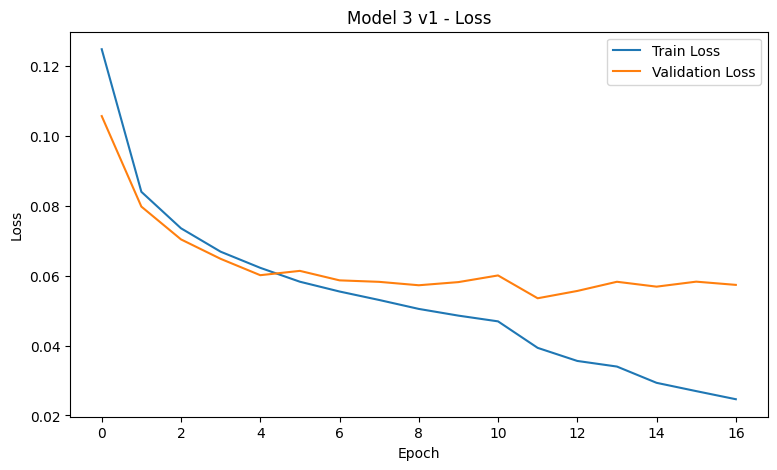

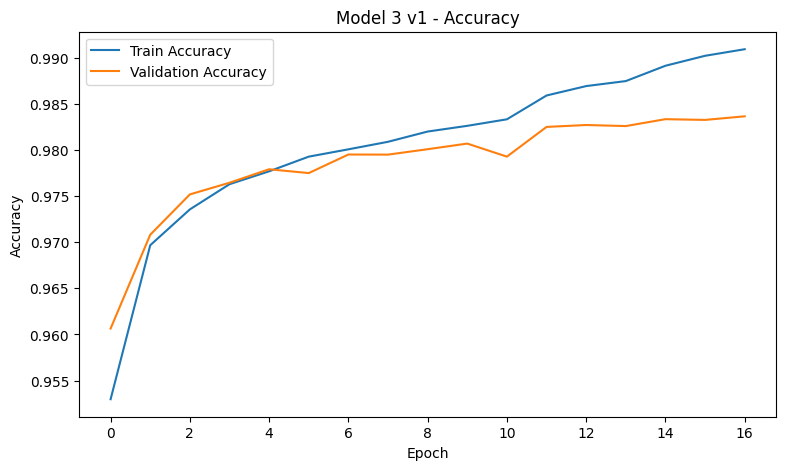

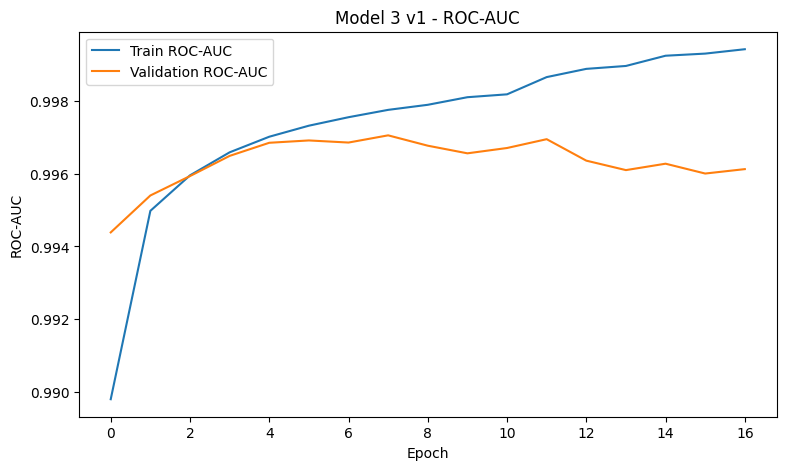

In [23]:
plt.figure(figsize=(9, 5))
plt.plot(
    history_3_v1.history["loss"],
    label="Train Loss"
)
plt.plot(
    history_3_v1.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 3 v1 - Loss")
plt.legend()
plt.savefig(
    f"{PLOT_DIR}/model_3_v1_loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.figure(figsize=(9, 5))
plt.plot(
    history_3_v1.history["accuracy"],
    label="Train Accuracy"
)
plt.plot(
    history_3_v1.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model 3 v1 - Accuracy")
plt.legend()
plt.savefig(
    f"{PLOT_DIR}/model_3_v1_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.figure(figsize=(9, 5))
plt.plot(
    history_3_v1.history["auc"],
    label="Train ROC-AUC"
)
plt.plot(
    history_3_v1.history["val_auc"],
    label="Validation ROC-AUC"
)
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Model 3 v1 - ROC-AUC")
plt.legend()
plt.savefig(
    f"{PLOT_DIR}/model_3_v1_roc_auc.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [24]:
val_prob_3_v1 = model_3_v1.predict(
    X_val_pad,
    batch_size=512
).ravel()

np.save(
    f"{ARRAY_DIR}/model_3_v1_validation_probabilities.npy",
    val_prob_3_v1
)
best_threshold_3_v1, best_val_f1_3_v1, threshold_df_3_v1 = (
    find_best_threshold(
        y_val,
        val_prob_3_v1
    )
)

print("Best threshold:", best_threshold_3_v1)
print("Best validation F1:", best_val_f1_3_v1)

display(
    threshold_df_3_v1
    .sort_values("f1", ascending=False)
    .head(15)
)

threshold_df_3_v1.to_csv(
    f"{RESULT_DIR}/model_3_v1_threshold_search.csv",
    index=False
)

170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step
Best threshold: 0.5749999999999997
Best validation F1: 0.9790058015776952


,threshold,precision,recall,f1
105,0.575,0.984168,0.973898,0.979006
108,0.590,0.984763,0.973206,0.978950
93,0.515,0.981631,0.976278,0.978947
107,0.585,0.984627,0.973316,0.978939
106,0.580,0.984355,0.973565,0.978931
96,0.530,0.982221,0.975641,0.978920
109,0.595,0.984953,0.972957,0.978918
104,0.570,0.983840,0.974036,0.978913
103,0.565,0.983542,0.974313,0.978906
110,0.600,0.985088,0.972790,0.978901


In [25]:
test_prob_3_v1 = model_3_v1.predict(
    X_test_pad,
    batch_size=512
).ravel()

result_3_v1, test_pred_3_v1 = evaluate_probabilities(
    y_true=y_test,
    y_prob=test_prob_3_v1,
    model_name="Model 3 v1 - Character CNN-BiLSTM",
    threshold=best_threshold_3_v1
)

170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step

Model 3 v1 - Character CNN-BiLSTM
              precision    recall  f1-score   support

           0   0.980802  0.988419  0.984596     50861
           1   0.983516  0.972763  0.978110     36127

    accuracy                       0.981917     86988
   macro avg   0.982159  0.980591  0.981353     86988
weighted avg   0.981929  0.981917  0.981902     86988

Confusion Matrix:
[[50272   589]
 [  984 35143]]
{'Model': 'Model 3 v1 - Character CNN-BiLSTM', 'Threshold': 0.5749999999999997, 'Accuracy': 0.9819170460293374, 'Precision': 0.9835161759767156, 'Recall': 0.9727627536191767, 'F1-score': 0.9781099096842427, 'ROC-AUC': 0.9979459160701989, 'PR-AUC': 0.9974862800422245, 'TN': 50272, 'FP': 589, 'FN': 984, 'TP': 35143}


In [26]:
result_3_v1["Validation F1"] = float(
    best_val_f1_3_v1
)

result_3_v1_df = pd.DataFrame([
    result_3_v1
])

result_3_v1_df.to_csv(
    f"{RESULT_DIR}/model_3_v1_results.csv",
    index=False
)

np.save(
    f"{ARRAY_DIR}/model_3_v1_test_probabilities.npy",
    test_prob_3_v1
)

np.save(
    f"{ARRAY_DIR}/model_3_v1_test_predictions.npy",
    test_pred_3_v1
)

print("Model 3 v1 sonuçları kaydedildi.")

Model 3 v1 sonuçları kaydedildi.


In [27]:
model_3_v1.save(
    f"{MODEL_DIR}/model_3_v1_cnn_bilstm_final.keras"
)

print("Final model kaydedildi.")

Final model kaydedildi.


SYSTEM INFORMATION
TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

Kayıt klasörü: /kaggle/working/model_3_v2_deep_cnn_bilstm

DATASET LOADING
Dataset shape: (579920, 2)

Label counts:
label
0    339074
1    240846
Name: count, dtype: int64

Label ratios:
label
0    0.584691
1    0.415309
Name: proportion, dtype: float64

İlk satırlar:
                                                 url  label
0  http://%20%25**)(**@fbrasil.com/old/lqjj0ukuvg...      1
1  https://*f003.backblazeb2.com*/file/pesosi/hom...      1
2  http://0-docusign-secured-843439-1-srs09.repli...      1
3                          http://0-olx.1850943.xyz/      1
4                http://0.0.0.0forum.cryptonight.net      1

URL length statistics:
{'mean': 51.629569595806316, 'median': 41.0, 'p90': 82.0, 'p95': 110.0, 'p99': 212.0, 'maximum': 25523, 'truncation_rate_at_250': 0.006856118085253138}


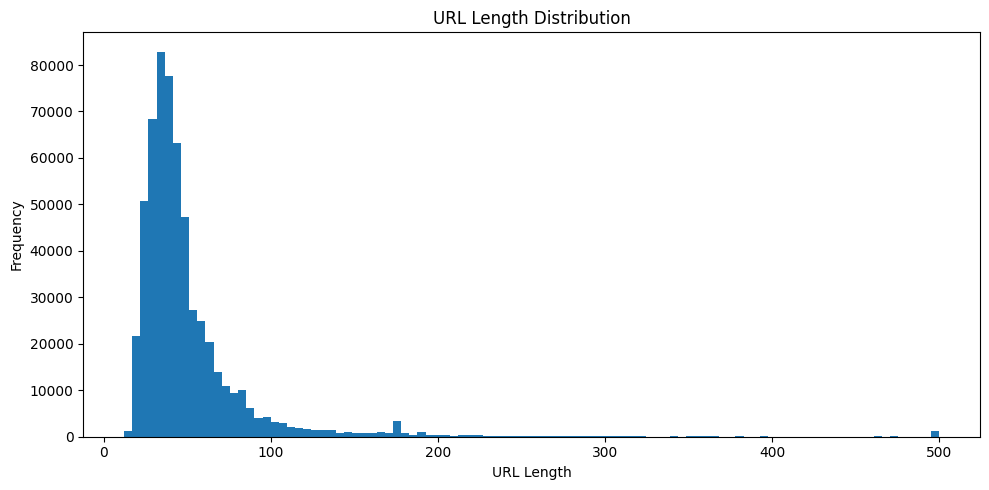


DATA SPLIT
Train samples: 405944
Validation samples: 86988
Test samples: 86988

Train label counts:
0    237352
1    168592
Name: count, dtype: int64

Validation label counts:
0    50861
1    36127
Name: count, dtype: int64

Test label counts:
0    50861
1    36127
Name: count, dtype: int64

Split bilgileri ve label dizileri kaydedildi.

CHARACTER TOKENIZATION
Tokenizer word_index size: 880
Model vocab size: 150
İlk karakterler:
[('<OOV>', 1), ('t', 2), ('/', 3), ('e', 4), ('s', 5), ('o', 6), ('a', 7), ('p', 8), ('.', 9), ('i', 10), ('c', 11), ('r', 12), ('n', 13), ('h', 14), ('w', 15), ('m', 16), ('l', 17), ('d', 18), ('-', 19), ('u', 20), (':', 21), ('g', 22), ('b', 23), ('f', 24), ('k', 25), ('y', 26), ('v', 27), ('2', 28), ('0', 29), ('1', 30)]
Tokenizer PKL ve JSON olarak kaydedildi.

Padding shapes:
Train: (405944, 250)
Validation: (86988, 250)
Test: (86988, 250)

Class weights:
{0: 0.8551518419899559, 1: 1.203924266869128}

MODEL 3 v2 ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ character_embedding (Embedding) │ (None, 250, 96)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_block_1 (Conv1D)         │ (None, 250, 128)       │        61,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_batch_normalization_1      │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_1 (MaxPooling1D)    │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_dropout_1 (Dropout)         │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_block_2 (Conv1D)         │ (None, 125, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_batch_normalization_2      │ (None, 125, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_2 (MaxPooling1D)    │ (None, 62, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_dropout_2 (Dropout)         │ (None, 62, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ (None, 192)            │       172,800 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_batch_normalization        │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout_128 (Dropout)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout_64 (Dropout)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,865 (1.27 MB)

 Trainable params: 331,969 (1.27 MB)

 Non-trainable params: 896 (3.50 KB)


Model konfigürasyonu kaydedildi.

MODEL TRAINING
Epoch 1/35
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8901 - auc: 0.9534 - loss: 0.2468 - pr_auc: 0.9384
Epoch 1: val_loss improved from None to 0.09757, saving model to /kaggle/working/model_3_v2_deep_cnn_bilstm/models/model_3_v2_deep_character_cnn_bilstm.keras

Epoch 1: finished saving model to /kaggle/working/model_3_v2_deep_cnn_bilstm/models/model_3_v2_deep_character_cnn_bilstm.keras
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 78s 45ms/step - accuracy: 0.9350 - auc: 0.9835 - loss: 0.1625 - pr_auc: 0.9782 - val_accuracy: 0.9656 - val_auc: 0.9931 - val_loss: 0.0976 - val_pr_auc: 0.9914 - learning_rate: 5.0000e-04
Epoch 2/35
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9615 - auc: 0.9926 - loss: 0.1043 - pr_auc: 0.9902
Epoch 2: val_loss did not improve from 0.09757
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.9639 - auc: 0.9934 - loss: 0.0981 - pr_auc: 0.9912 - val_accuracy: 0.9654 - val_auc: 0.9941 - val_l

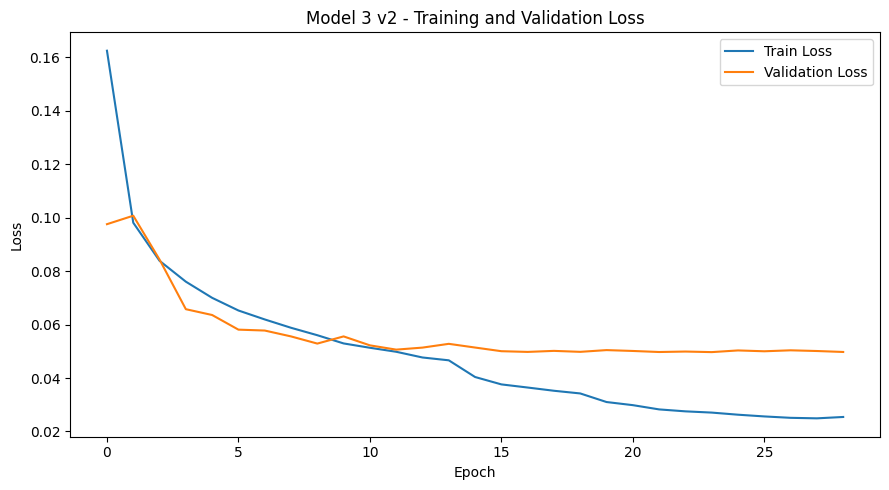

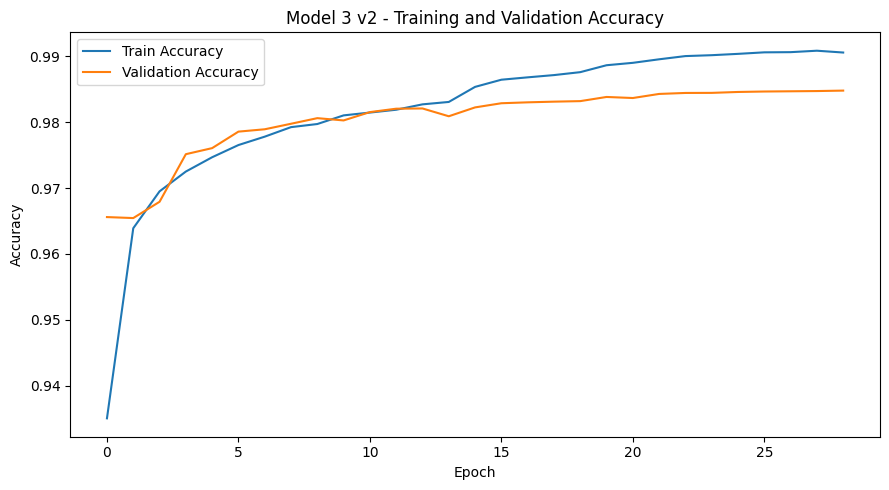

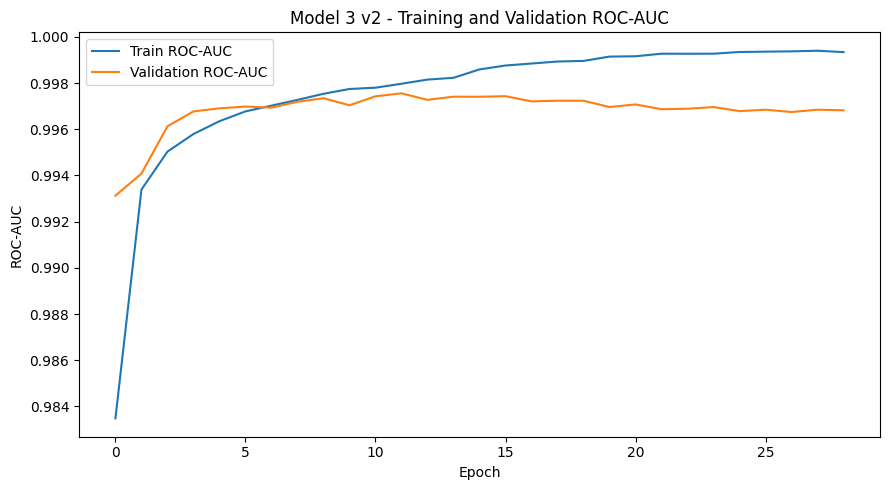

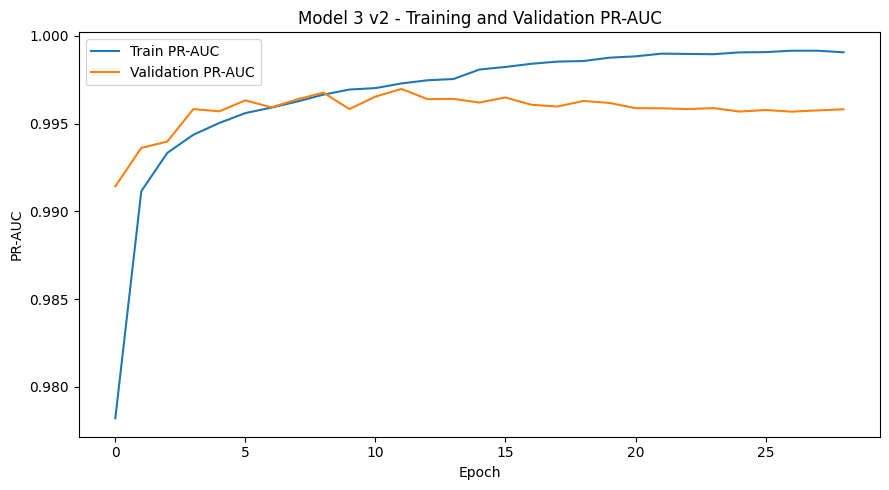


Validation probabilities are being generated...
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step

Best threshold: 0.5799999999999997
Best validation F1: 0.9817504551961861

Top threshold results:
     threshold  precision    recall        f1
106      0.580   0.985958  0.977579  0.981750
113      0.615   0.986827  0.976693  0.981734
112      0.610   0.986609  0.976859  0.981710
114      0.620   0.986962  0.976472  0.981689
115      0.625   0.987153  0.976278  0.981686
107      0.585   0.985982  0.977385  0.981665
108      0.590   0.986091  0.977275  0.981663
103      0.565   0.985467  0.977884  0.981661
111      0.605   0.986444  0.976915  0.981656
110      0.600   0.986281  0.977053  0.981645
104      0.570   0.985575  0.977745  0.981644
105      0.575   0.985656  0.977662  0.981643
116      0.630   0.987289  0.976057  0.981641
109      0.595   0.986199  0.977109  0.981633
117      0.635   0.987425  0.975891  0.981624


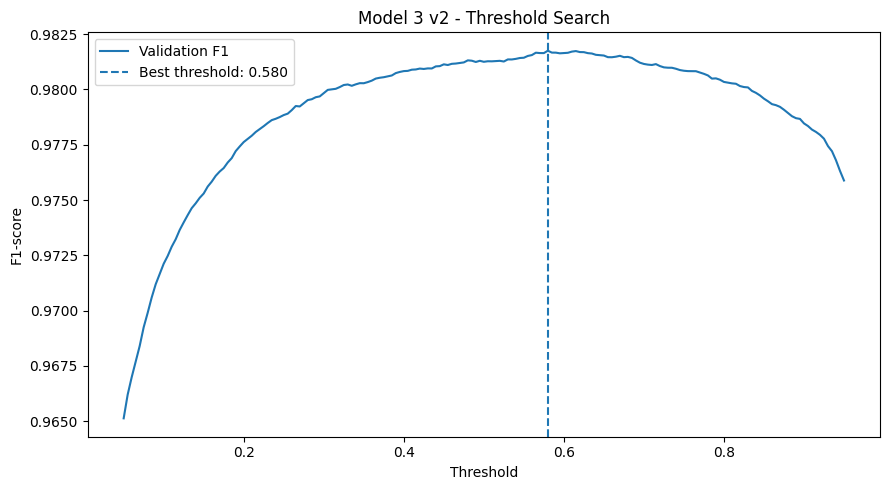


Test probabilities are being generated...
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step

Model 3 v2 - Deep Character CNN-BiLSTM
              precision    recall  f1-score   support

           0   0.982486  0.989363  0.985913     50861
           1   0.984876  0.975171  0.979999     36127

    accuracy                       0.983469     86988
   macro avg   0.983681  0.982267  0.982956     86988
weighted avg   0.983479  0.983469  0.983457     86988

Confusion Matrix:
[[50320   541]
 [  897 35230]]

Result dictionary:
{'Model': 'Model 3 v2 - Deep Character CNN-BiLSTM', 'Threshold': 0.5799999999999997, 'Accuracy': 0.9834689842277096, 'Precision': 0.9848760168851863, 'Recall': 0.9751709247930911, 'F1-score': 0.9799994436562909, 'ROC-AUC': 0.9981785089333113, 'PR-AUC': 0.9977804311843987, 'TN': 50320, 'FP': 541, 'FN': 897, 'TP': 35230}

Test sonuçları ve tahminler kaydedildi.


<Figure size 600x600 with 0 Axes>

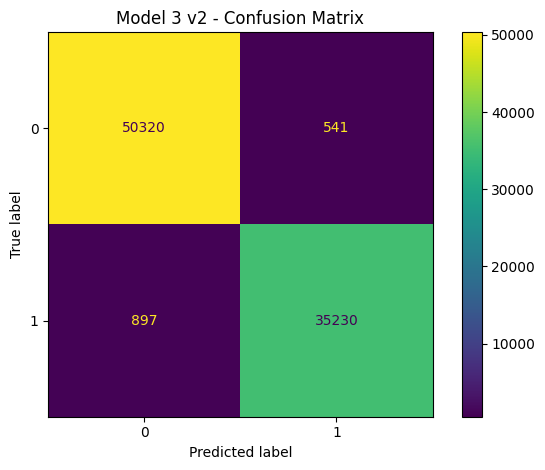

<Figure size 700x600 with 0 Axes>

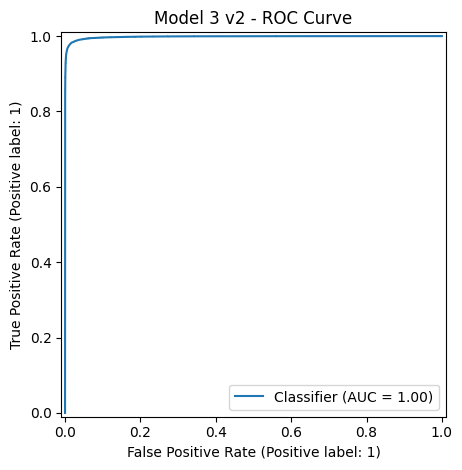

<Figure size 700x600 with 0 Axes>

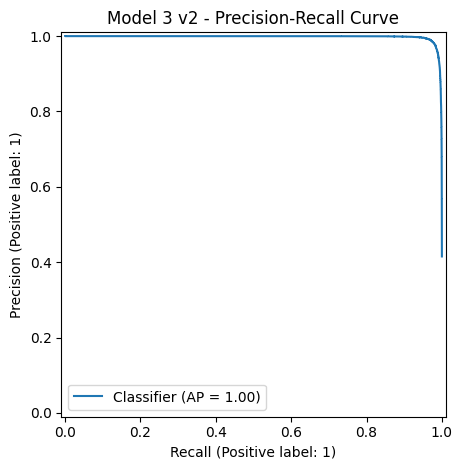


Final model saved:
/kaggle/working/model_3_v2_deep_cnn_bilstm/models/model_3_v2_deep_cnn_bilstm_final.keras

MODEL 3 v1 - v2 COMPARISON
                                    Model  Threshold  Accuracy  Precision  \
0       Model 3 v1 - Character CNN-BiLSTM      0.385  0.981170   0.978363   
1  Model 3 v2 - Deep Character CNN-BiLSTM      0.580  0.983469   0.984876   

     Recall  F1-score   ROC-AUC    PR-AUC     TN   FP   FN     TP  \
0  0.976250  0.977305  0.997987  0.997535  50081  780  858  35269   
1  0.975171  0.979999  0.998179  0.997780  50320  541  897  35230   

   Validation F1  Best Epoch  Best Validation Loss  
0            NaN         NaN                   NaN  
1        0.98175        24.0              0.049699  

ALL MODEL COMPARISON
                                              Model  Threshold  Accuracy  \
0             Model 1 - Character CNN Seed Ensemble      0.410  0.983768   
1  Model 2 - Stacked Character BiLSTM Seed Ensemble      0.515  0.980043   
2             

/kaggle/working/model_3_v2_deep_cnn_bilstm_complete.zip


MODEL 3 v2 PROCESS COMPLETED
Best validation threshold: 0.5799999999999997
Best validation F1: 0.9817504551961861
Test accuracy: 0.9834689842277096
Test precision: 0.9848760168851863
Test recall: 0.9751709247930911
Test F1: 0.9799994436562909
Test ROC-AUC: 0.9981785089333113
Test PR-AUC: 0.9977804311843987
Confusion matrix:
[[50320, 541], [897, 35230]]
ZIP: /kaggle/working/model_3_v2_deep_cnn_bilstm_complete.zip


In [28]:
# ============================================================
# MODEL 3 v2 - DEEP CHARACTER CNN-BiLSTM
# Raw URL-based Phishing Detection
# ============================================================

# ============================================================
# 1. IMPORTS VE TEKRARLANABİLİRLİK
# ============================================================

import os

# TensorFlow loglarını azaltır.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import gc
import json
import pickle
import random
import shutil
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    Dropout,
    Bidirectional,
    LSTM,
    Dense
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 70)
print("SYSTEM INFORMATION")
print("=" * 70)
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


# ============================================================
# 2. DOSYA VE KLASÖR AYARLARI
# ============================================================

CSV_PATH = (
    "/kaggle/input/datasets/elifzelik/"
    "phishing-url-features-dataset/final_dataset.csv"
)

BASE_SAVE_DIR = "/kaggle/working/model_3_v2_deep_cnn_bilstm"

MODEL_DIR = f"{BASE_SAVE_DIR}/models"
RESULT_DIR = f"{BASE_SAVE_DIR}/results"
ARRAY_DIR = f"{BASE_SAVE_DIR}/arrays"
CONFIG_DIR = f"{BASE_SAVE_DIR}/config"
LOG_DIR = f"{BASE_SAVE_DIR}/logs"
PLOT_DIR = f"{BASE_SAVE_DIR}/plots"

for directory in [
    BASE_SAVE_DIR,
    MODEL_DIR,
    RESULT_DIR,
    ARRAY_DIR,
    CONFIG_DIR,
    LOG_DIR,
    PLOT_DIR
]:
    os.makedirs(directory, exist_ok=True)

MODEL_NAME = "model_3_v2_deep_character_cnn_bilstm"

print("\nKayıt klasörü:", BASE_SAVE_DIR)


# ============================================================
# 3. HİPERPARAMETRELER
# ============================================================

MAX_LEN = 250
MAX_CHARS = 150

EMBEDDING_DIM = 96

CNN_FILTERS_1 = 128
CNN_KERNEL_SIZE_1 = 5

CNN_FILTERS_2 = 128
CNN_KERNEL_SIZE_2 = 3

LSTM_UNITS = 96

CNN_DROPOUT_1 = 0.20
CNN_DROPOUT_2 = 0.20

DENSE_UNITS_1 = 128
DENSE_UNITS_2 = 64

DENSE_DROPOUT_1 = 0.30
DENSE_DROPOUT_2 = 0.20

LEARNING_RATE = 5e-4
BATCH_SIZE = 256
EPOCHS = 35


# ============================================================
# 4. DATASET YÜKLEME
# ============================================================

print("\n" + "=" * 70)
print("DATASET LOADING")
print("=" * 70)

df = pd.read_csv(
    CSV_PATH,
    usecols=["url", "label"]
)

df = df.dropna(subset=["url", "label"]).copy()

df["url"] = df["url"].astype(str)
df["label"] = df["label"].astype(np.int8)

print("Dataset shape:", df.shape)

print("\nLabel counts:")
print(df["label"].value_counts().sort_index())

print("\nLabel ratios:")
print(df["label"].value_counts(normalize=True).sort_index())

print("\nİlk satırlar:")
print(df.head())


# ============================================================
# 5. URL UZUNLUK İSTATİSTİKLERİ
# ============================================================

url_lengths = df["url"].str.len()

url_length_statistics = {
    "mean": float(url_lengths.mean()),
    "median": float(url_lengths.median()),
    "p90": float(np.percentile(url_lengths, 90)),
    "p95": float(np.percentile(url_lengths, 95)),
    "p99": float(np.percentile(url_lengths, 99)),
    "maximum": int(url_lengths.max()),
    "truncation_rate_at_250": float(
        (url_lengths > MAX_LEN).mean()
    )
}

print("\nURL length statistics:")
print(url_length_statistics)

with open(
    f"{CONFIG_DIR}/url_length_statistics.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        url_length_statistics,
        file,
        indent=4,
        ensure_ascii=False
    )

plt.figure(figsize=(10, 5))
plt.hist(
    url_lengths.clip(upper=500),
    bins=100
)
plt.title("URL Length Distribution")
plt.xlabel("URL Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(
    f"{PLOT_DIR}/url_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ============================================================
# 6. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

urls = df["url"].to_numpy()
labels = df["label"].to_numpy()

X_train_url, X_temp_url, y_train, y_temp = train_test_split(
    urls,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

X_val_url, X_test_url, y_val, y_test = train_test_split(
    X_temp_url,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("\n" + "=" * 70)
print("DATA SPLIT")
print("=" * 70)

print("Train samples:", len(X_train_url))
print("Validation samples:", len(X_val_url))
print("Test samples:", len(X_test_url))

print("\nTrain label counts:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation label counts:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest label counts:")
print(pd.Series(y_test).value_counts().sort_index())


# ============================================================
# 7. SPLIT BİLGİLERİNİ KAYDET
# ============================================================

split_information = {
    "dataset_path": CSV_PATH,
    "total_samples": int(len(df)),
    "train_samples": int(len(X_train_url)),
    "validation_samples": int(len(X_val_url)),
    "test_samples": int(len(X_test_url)),
    "train_ratio": 0.70,
    "validation_ratio": 0.15,
    "test_ratio": 0.15,
    "random_state": SEED,
    "stratified": True,
    "duplicate_urls_removed": False,
    "train_label_counts": {
        str(key): int(value)
        for key, value in pd.Series(
            y_train
        ).value_counts().sort_index().to_dict().items()
    },
    "validation_label_counts": {
        str(key): int(value)
        for key, value in pd.Series(
            y_val
        ).value_counts().sort_index().to_dict().items()
    },
    "test_label_counts": {
        str(key): int(value)
        for key, value in pd.Series(
            y_test
        ).value_counts().sort_index().to_dict().items()
    }
}

with open(
    f"{CONFIG_DIR}/data_split_information.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        split_information,
        file,
        indent=4,
        ensure_ascii=False
    )

np.save(f"{ARRAY_DIR}/y_train.npy", y_train)
np.save(f"{ARRAY_DIR}/y_validation.npy", y_val)
np.save(f"{ARRAY_DIR}/y_test.npy", y_test)

print("\nSplit bilgileri ve label dizileri kaydedildi.")


# ============================================================
# 8. CHARACTER-LEVEL TOKENIZER
# ============================================================

print("\n" + "=" * 70)
print("CHARACTER TOKENIZATION")
print("=" * 70)

tokenizer = Tokenizer(
    num_words=MAX_CHARS,
    char_level=True,
    lower=False,
    oov_token="<OOV>"
)

# Tokenizer yalnızca train setinde öğrenir.
tokenizer.fit_on_texts(X_train_url)

vocab_size = min(
    MAX_CHARS,
    len(tokenizer.word_index) + 1
)

print("Tokenizer word_index size:", len(tokenizer.word_index))
print("Model vocab size:", vocab_size)
print("İlk karakterler:")
print(list(tokenizer.word_index.items())[:30])

with open(
    f"{CONFIG_DIR}/url_character_tokenizer.pkl",
    "wb"
) as file:
    pickle.dump(tokenizer, file)

tokenizer_json = tokenizer.to_json()

with open(
    f"{CONFIG_DIR}/url_character_tokenizer.json",
    "w",
    encoding="utf-8"
) as file:
    file.write(tokenizer_json)

print("Tokenizer PKL ve JSON olarak kaydedildi.")


# ============================================================
# 9. URL'LERİ SEQUENCE VE PADDING FORMATINA DÖNÜŞTÜR
# ============================================================

X_train_sequences = tokenizer.texts_to_sequences(X_train_url)
X_val_sequences = tokenizer.texts_to_sequences(X_val_url)
X_test_sequences = tokenizer.texts_to_sequences(X_test_url)

X_train_pad = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    dtype="int32"
)

X_val_pad = pad_sequences(
    X_val_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    dtype="int32"
)

X_test_pad = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    dtype="int32"
)

print("\nPadding shapes:")
print("Train:", X_train_pad.shape)
print("Validation:", X_val_pad.shape)
print("Test:", X_test_pad.shape)

del X_train_sequences
del X_val_sequences
del X_test_sequences

gc.collect()


# ============================================================
# 10. CLASS WEIGHT HESAPLAMA
# ============================================================

classes = np.unique(y_train)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = {
    int(label): float(weight)
    for label, weight in zip(
        classes,
        class_weight_values
    )
}

print("\nClass weights:")
print(class_weight)


# ============================================================
# 11. THRESHOLD ARAMA FONKSİYONU
# ============================================================

def find_best_threshold(
    y_true,
    y_probability,
    start=0.05,
    stop=0.95,
    step=0.005
):
    thresholds = np.arange(
        start,
        stop + step,
        step
    )

    records = []

    best_threshold = 0.5
    best_f1 = -1.0

    for threshold in thresholds:
        predictions = (
            y_probability >= threshold
        ).astype(np.int8)

        precision = precision_score(
            y_true,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            predictions,
            zero_division=0
        )

        records.append({
            "threshold": float(threshold),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1)
        })

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    threshold_dataframe = pd.DataFrame(records)

    return (
        float(best_threshold),
        float(best_f1),
        threshold_dataframe
    )


# ============================================================
# 12. DEĞERLENDİRME FONKSİYONU
# ============================================================

def evaluate_probabilities(
    y_true,
    y_probability,
    model_name,
    threshold
):
    predictions = (
        y_probability >= threshold
    ).astype(np.int8)

    matrix = confusion_matrix(
        y_true,
        predictions
    )

    tn, fp, fn, tp = matrix.ravel()

    result = {
        "Model": model_name,
        "Threshold": float(threshold),
        "Accuracy": float(
            accuracy_score(
                y_true,
                predictions
            )
        ),
        "Precision": float(
            precision_score(
                y_true,
                predictions,
                zero_division=0
            )
        ),
        "Recall": float(
            recall_score(
                y_true,
                predictions,
                zero_division=0
            )
        ),
        "F1-score": float(
            f1_score(
                y_true,
                predictions,
                zero_division=0
            )
        ),
        "ROC-AUC": float(
            roc_auc_score(
                y_true,
                y_probability
            )
        ),
        "PR-AUC": float(
            average_precision_score(
                y_true,
                y_probability
            )
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_true,
            predictions,
            digits=6,
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(matrix)

    print("\nResult dictionary:")
    print(result)

    return result, predictions


# ============================================================
# 13. CALLBACK FONKSİYONU
# ============================================================

def build_callbacks(model_name):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),

        ModelCheckpoint(
            filepath=f"{MODEL_DIR}/{model_name}.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),

        CSVLogger(
            filename=(
                f"{LOG_DIR}/"
                f"{model_name}_training_log.csv"
            ),
            append=False
        )
    ]


# ============================================================
# 14. MODEL 3 v2 MİMARİSİ
# ============================================================

def create_deep_cnn_bilstm_model(
    vocab_size,
    max_len,
    embedding_dim=96,
    filters_1=128,
    kernel_size_1=5,
    filters_2=128,
    kernel_size_2=3,
    lstm_units=96,
    learning_rate=5e-4
):
    model = Sequential([
        Input(
            shape=(max_len,),
            name="url_character_input"
        ),

        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            name="character_embedding"
        ),

        Conv1D(
            filters=filters_1,
            kernel_size=kernel_size_1,
            padding="same",
            activation="relu",
            name="conv1d_block_1"
        ),

        BatchNormalization(
            name="conv_batch_normalization_1"
        ),

        MaxPooling1D(
            pool_size=2,
            name="max_pooling_1"
        ),

        Dropout(
            CNN_DROPOUT_1,
            name="cnn_dropout_1"
        ),

        Conv1D(
            filters=filters_2,
            kernel_size=kernel_size_2,
            padding="same",
            activation="relu",
            name="conv1d_block_2"
        ),

        BatchNormalization(
            name="conv_batch_normalization_2"
        ),

        MaxPooling1D(
            pool_size=2,
            name="max_pooling_2"
        ),

        Dropout(
            CNN_DROPOUT_2,
            name="cnn_dropout_2"
        ),

        Bidirectional(
            LSTM(
                lstm_units,
                return_sequences=False,
                dropout=0.0,
                recurrent_dropout=0.0
            ),
            name="bidirectional_lstm"
        ),

        BatchNormalization(
            name="lstm_batch_normalization"
        ),

        Dense(
            DENSE_UNITS_1,
            activation="relu",
            name="dense_128"
        ),

        Dropout(
            DENSE_DROPOUT_1,
            name="dense_dropout_128"
        ),

        Dense(
            DENSE_UNITS_2,
            activation="relu",
            name="dense_64"
        ),

        Dropout(
            DENSE_DROPOUT_2,
            name="dense_dropout_64"
        ),

        Dense(
            1,
            activation="sigmoid",
            name="output"
        )
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",

            tf.keras.metrics.AUC(
                name="auc",
                curve="ROC"
            ),

            tf.keras.metrics.AUC(
                name="pr_auc",
                curve="PR"
            )
        ]
    )

    return model


# ============================================================
# 15. MODELİ OLUŞTUR
# ============================================================

tf.keras.backend.clear_session()
gc.collect()

model_3_v2 = create_deep_cnn_bilstm_model(
    vocab_size=vocab_size,
    max_len=MAX_LEN,
    embedding_dim=EMBEDDING_DIM,
    filters_1=CNN_FILTERS_1,
    kernel_size_1=CNN_KERNEL_SIZE_1,
    filters_2=CNN_FILTERS_2,
    kernel_size_2=CNN_KERNEL_SIZE_2,
    lstm_units=LSTM_UNITS,
    learning_rate=LEARNING_RATE
)

print("\n" + "=" * 70)
print("MODEL 3 v2 ARCHITECTURE")
print("=" * 70)

model_3_v2.summary()


# ============================================================
# 16. MODEL MİMARİSİNİ KAYDET
# ============================================================

summary_lines = []

model_3_v2.summary(
    print_fn=lambda line: summary_lines.append(line)
)

with open(
    f"{CONFIG_DIR}/model_3_v2_architecture.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write("\n".join(summary_lines))


# ============================================================
# 17. MODEL KONFİGÜRASYONUNU KAYDET
# ============================================================

model_configuration = {
    "model_name": (
        "Model 3 v2 - Deep Character CNN-BiLSTM"
    ),
    "input_type": "Raw URL characters only",
    "used_columns": ["url", "label"],
    "handcrafted_features_used": False,
    "dataset_path": CSV_PATH,
    "random_state": SEED,

    "data_split": {
        "train": 0.70,
        "validation": 0.15,
        "test": 0.15,
        "stratified": True
    },

    "preprocessing": {
        "tokenization": "character-level",
        "max_len": MAX_LEN,
        "max_chars": MAX_CHARS,
        "vocab_size": int(vocab_size),
        "padding": "post",
        "truncating": "post",
        "lower": False,
        "oov_token": "<OOV>"
    },

    "architecture": {
        "embedding_dim": EMBEDDING_DIM,

        "cnn_block_1": {
            "filters": CNN_FILTERS_1,
            "kernel_size": CNN_KERNEL_SIZE_1,
            "padding": "same",
            "activation": "relu",
            "batch_normalization": True,
            "pool_size": 2,
            "dropout": CNN_DROPOUT_1
        },

        "cnn_block_2": {
            "filters": CNN_FILTERS_2,
            "kernel_size": CNN_KERNEL_SIZE_2,
            "padding": "same",
            "activation": "relu",
            "batch_normalization": True,
            "pool_size": 2,
            "dropout": CNN_DROPOUT_2
        },

        "bidirectional_lstm": {
            "units_per_direction": LSTM_UNITS,
            "return_sequences": False,
            "dropout": 0.0,
            "recurrent_dropout": 0.0
        },

        "dense_layers": [
            {
                "units": DENSE_UNITS_1,
                "activation": "relu",
                "dropout": DENSE_DROPOUT_1
            },
            {
                "units": DENSE_UNITS_2,
                "activation": "relu",
                "dropout": DENSE_DROPOUT_2
            }
        ],

        "output": {
            "units": 1,
            "activation": "sigmoid"
        }
    },

    "training": {
        "optimizer": "Adam",
        "initial_learning_rate": LEARNING_RATE,
        "loss": "binary_crossentropy",
        "batch_size": BATCH_SIZE,
        "maximum_epochs": EPOCHS,
        "class_weight": {
            str(key): float(value)
            for key, value in class_weight.items()
        },
        "early_stopping_monitor": "val_loss",
        "early_stopping_patience": 5,
        "model_checkpoint_monitor": "val_loss",
        "reduce_lr_monitor": "val_loss",
        "reduce_lr_factor": 0.5,
        "reduce_lr_patience": 2,
        "minimum_learning_rate": 1e-6
    }
}

with open(
    f"{CONFIG_DIR}/model_3_v2_configuration.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_configuration,
        file,
        indent=4,
        ensure_ascii=False
    )

print("\nModel konfigürasyonu kaydedildi.")


# ============================================================
# 18. MODEL EĞİTİMİ
# ============================================================

print("\n" + "=" * 70)
print("MODEL TRAINING")
print("=" * 70)

history_3_v2 = model_3_v2.fit(
    X_train_pad,
    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,

    class_weight=class_weight,

    callbacks=build_callbacks(
        MODEL_NAME
    ),

    verbose=1
)


# ============================================================
# 19. EĞİTİM GEÇMİŞİNİ KAYDET
# ============================================================

history_dataframe = pd.DataFrame(
    history_3_v2.history
)

history_dataframe.index = (
    history_dataframe.index + 1
)

history_dataframe.index.name = "epoch"

history_dataframe.to_csv(
    f"{LOG_DIR}/model_3_v2_training_history.csv"
)

best_epoch_by_val_loss = int(
    history_dataframe["val_loss"].idxmin()
)

best_val_loss = float(
    history_dataframe["val_loss"].min()
)

print("\nBest epoch by validation loss:", best_epoch_by_val_loss)
print("Best validation loss:", best_val_loss)


# ============================================================
# 20. EĞİTİM GRAFİKLERİNİ KAYDET
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(
    history_3_v2.history["loss"],
    label="Train Loss"
)
plt.plot(
    history_3_v2.history["val_loss"],
    label="Validation Loss"
)
plt.title("Model 3 v2 - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(
    f"{PLOT_DIR}/model_3_v2_loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


plt.figure(figsize=(9, 5))
plt.plot(
    history_3_v2.history["accuracy"],
    label="Train Accuracy"
)
plt.plot(
    history_3_v2.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title("Model 3 v2 - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(
    f"{PLOT_DIR}/model_3_v2_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


plt.figure(figsize=(9, 5))
plt.plot(
    history_3_v2.history["auc"],
    label="Train ROC-AUC"
)
plt.plot(
    history_3_v2.history["val_auc"],
    label="Validation ROC-AUC"
)
plt.title("Model 3 v2 - Training and Validation ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.legend()
plt.tight_layout()
plt.savefig(
    f"{PLOT_DIR}/model_3_v2_roc_auc.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


plt.figure(figsize=(9, 5))
plt.plot(
    history_3_v2.history["pr_auc"],
    label="Train PR-AUC"
)
plt.plot(
    history_3_v2.history["val_pr_auc"],
    label="Validation PR-AUC"
)
plt.title("Model 3 v2 - Training and Validation PR-AUC")
plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.legend()
plt.tight_layout()
plt.savefig(
    f"{PLOT_DIR}/model_3_v2_pr_auc.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ============================================================
# 21. VALIDATION TAHMİNLERİ
# ============================================================

print("\nValidation probabilities are being generated...")

validation_probabilities = model_3_v2.predict(
    X_val_pad,
    batch_size=512,
    verbose=1
).ravel()

np.save(
    f"{ARRAY_DIR}/model_3_v2_validation_probabilities.npy",
    validation_probabilities
)


# ============================================================
# 22. VALIDATION SETİNDE THRESHOLD TUNING
# ============================================================

(
    best_threshold,
    best_validation_f1,
    threshold_dataframe
) = find_best_threshold(
    y_val,
    validation_probabilities
)

print("\nBest threshold:", best_threshold)
print("Best validation F1:", best_validation_f1)

print("\nTop threshold results:")
print(
    threshold_dataframe
    .sort_values(
        "f1",
        ascending=False
    )
    .head(15)
)

threshold_dataframe.to_csv(
    f"{RESULT_DIR}/model_3_v2_threshold_search.csv",
    index=False
)

plt.figure(figsize=(9, 5))
plt.plot(
    threshold_dataframe["threshold"],
    threshold_dataframe["f1"],
    label="Validation F1"
)
plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold: {best_threshold:.3f}"
)
plt.title("Model 3 v2 - Threshold Search")
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.legend()
plt.tight_layout()
plt.savefig(
    f"{PLOT_DIR}/model_3_v2_threshold_search.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ============================================================
# 23. TEST TAHMİNLERİ
# ============================================================

print("\nTest probabilities are being generated...")

test_probabilities = model_3_v2.predict(
    X_test_pad,
    batch_size=512,
    verbose=1
).ravel()


# ============================================================
# 24. TEST DEĞERLENDİRMESİ
# ============================================================

test_result, test_predictions = evaluate_probabilities(
    y_true=y_test,
    y_probability=test_probabilities,
    model_name=(
        "Model 3 v2 - Deep Character CNN-BiLSTM"
    ),
    threshold=best_threshold
)

test_result["Validation F1"] = float(
    best_validation_f1
)

test_result["Best Epoch"] = (
    best_epoch_by_val_loss
)

test_result["Best Validation Loss"] = (
    best_val_loss
)


# ============================================================
# 25. SONUÇLARI KAYDET
# ============================================================

result_dataframe = pd.DataFrame([
    test_result
])

result_dataframe.to_csv(
    f"{RESULT_DIR}/model_3_v2_results.csv",
    index=False
)

with open(
    f"{RESULT_DIR}/model_3_v2_results.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        test_result,
        file,
        indent=4,
        ensure_ascii=False
    )

np.save(
    f"{ARRAY_DIR}/model_3_v2_test_probabilities.npy",
    test_probabilities
)

np.save(
    f"{ARRAY_DIR}/model_3_v2_test_predictions.npy",
    test_predictions
)

print("\nTest sonuçları ve tahminler kaydedildi.")


# ============================================================
# 26. CONFUSION MATRIX GRAFİĞİ
# ============================================================

plt.figure(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    values_format="d"
)

plt.title("Model 3 v2 - Confusion Matrix")
plt.tight_layout()
plt.savefig(
    f"{PLOT_DIR}/model_3_v2_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ============================================================
# 27. ROC CURVE
# ============================================================

plt.figure(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities
)

plt.title("Model 3 v2 - ROC Curve")
plt.tight_layout()
plt.savefig(
    f"{PLOT_DIR}/model_3_v2_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ============================================================
# 28. PRECISION-RECALL CURVE
# ============================================================

plt.figure(figsize=(7, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities
)

plt.title("Model 3 v2 - Precision-Recall Curve")
plt.tight_layout()
plt.savefig(
    f"{PLOT_DIR}/model_3_v2_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ============================================================
# 29. FINAL MODELİ KAYDET
# ============================================================

final_model_path = (
    f"{MODEL_DIR}/"
    "model_3_v2_deep_cnn_bilstm_final.keras"
)

model_3_v2.save(final_model_path)

print("\nFinal model saved:")
print(final_model_path)


# ============================================================
# 30. MODEL 3 v1 İLE KARŞILAŞTIRMA
# ============================================================

model_3_comparison = pd.DataFrame([
    {
        "Model": "Model 3 v1 - Character CNN-BiLSTM",
        "Threshold": 0.385,
        "Accuracy": 0.9811698165264174,
        "Precision": 0.9783627839884601,
        "Recall": 0.9762504498020871,
        "F1-score": 0.9773054755043228,
        "ROC-AUC": 0.9979868280848079,
        "PR-AUC": 0.9975354079375912,
        "TN": 50081,
        "FP": 780,
        "FN": 858,
        "TP": 35269
    },

    test_result
])

print("\n" + "=" * 70)
print("MODEL 3 v1 - v2 COMPARISON")
print("=" * 70)

print(model_3_comparison)

model_3_comparison.to_csv(
    f"{RESULT_DIR}/model_3_v1_v2_comparison.csv",
    index=False
)


# ============================================================
# 31. İLK ÜÇ FINAL MODELLE KARŞILAŞTIRMA
# ============================================================

all_models_comparison = pd.DataFrame([
    {
        "Model": "Model 1 - Character CNN Seed Ensemble",
        "Threshold": 0.410,
        "Accuracy": 0.9837678760288775,
        "Precision": 0.9861636277063552,
        "Recall": 0.9745896420959393,
        "F1-score": 0.9803424752888765,
        "ROC-AUC": 0.9984950774425538,
        "PR-AUC": 0.9981095389818174,
        "TN": 50367,
        "FP": 494,
        "FN": 918,
        "TP": 35209
    },

    {
        "Model": (
            "Model 2 - Stacked Character "
            "BiLSTM Seed Ensemble"
        ),
        "Threshold": 0.515,
        "Accuracy": 0.9800432243527842,
        "Precision": 0.9817611296332615,
        "Recall": 0.9699670606471614,
        "F1-score": 0.9758284600389864,
        "ROC-AUC": 0.9975758654449631,
        "PR-AUC": 0.997075478812562,
        "TN": 50210,
        "FP": 651,
        "FN": 1085,
        "TP": 35042
    },

    {
        "Model": "Model 3 v1 - Character CNN-BiLSTM",
        "Threshold": 0.385,
        "Accuracy": 0.9811698165264174,
        "Precision": 0.9783627839884601,
        "Recall": 0.9762504498020871,
        "F1-score": 0.9773054755043228,
        "ROC-AUC": 0.9979868280848079,
        "PR-AUC": 0.9975354079375912,
        "TN": 50081,
        "FP": 780,
        "FN": 858,
        "TP": 35269
    },

    test_result
])

print("\n" + "=" * 70)
print("ALL MODEL COMPARISON")
print("=" * 70)

print(all_models_comparison)

all_models_comparison.to_csv(
    f"{RESULT_DIR}/all_models_comparison.csv",
    index=False
)


# ============================================================
# 32. FINAL RAPOR METNİ
# ============================================================

report_text = f"""
MODEL 3 v2 FINAL REPORT
=======================

Model:
Model 3 v2 - Deep Character CNN-BiLSTM

Input:
Raw URL characters only.

Handcrafted Features:
Not used.

Dataset:
{CSV_PATH}

Data Split:
- Training: 70%
- Validation: 15%
- Test: 15%
- Random state: {SEED}
- Stratified: Yes

Preprocessing:
- Character-level tokenization
- Maximum character vocabulary: {MAX_CHARS}
- Actual vocabulary size: {vocab_size}
- Maximum URL length: {MAX_LEN}
- Padding: post
- Truncation: post

Architecture:
- Embedding dimension: {EMBEDDING_DIM}
- Conv1D block 1: {CNN_FILTERS_1} filters, kernel {CNN_KERNEL_SIZE_1}
- Batch normalization
- MaxPooling1D: pool size 2
- Dropout: {CNN_DROPOUT_1}
- Conv1D block 2: {CNN_FILTERS_2} filters, kernel {CNN_KERNEL_SIZE_2}
- Batch normalization
- MaxPooling1D: pool size 2
- Dropout: {CNN_DROPOUT_2}
- Bidirectional LSTM: {LSTM_UNITS} units per direction
- Dense: {DENSE_UNITS_1}, ReLU
- Dropout: {DENSE_DROPOUT_1}
- Dense: {DENSE_UNITS_2}, ReLU
- Dropout: {DENSE_DROPOUT_2}
- Output: sigmoid

Training:
- Optimizer: Adam
- Initial learning rate: {LEARNING_RATE}
- Loss: binary cross-entropy
- Batch size: {BATCH_SIZE}
- Maximum epochs: {EPOCHS}
- Best epoch by validation loss: {best_epoch_by_val_loss}
- Best validation loss: {best_val_loss}
- Balanced class weights: {class_weight}

Threshold Selection:
- Threshold selected only on validation data
- Best threshold: {best_threshold}
- Best validation F1: {best_validation_f1}

Final Test Results:
- Accuracy: {test_result["Accuracy"]}
- Precision: {test_result["Precision"]}
- Recall: {test_result["Recall"]}
- F1-score: {test_result["F1-score"]}
- ROC-AUC: {test_result["ROC-AUC"]}
- PR-AUC: {test_result["PR-AUC"]}

Confusion Matrix:
- TN: {test_result["TN"]}
- FP: {test_result["FP"]}
- FN: {test_result["FN"]}
- TP: {test_result["TP"]}
"""

with open(
    f"{RESULT_DIR}/model_3_v2_final_report.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(report_text)

print("\nFinal report saved.")


# ============================================================
# 33. DOSYA MANİFESTOSU
# ============================================================

manifest_records = []

for root, directories, files in os.walk(
    BASE_SAVE_DIR
):
    for filename in files:
        full_path = os.path.join(
            root,
            filename
        )

        relative_path = os.path.relpath(
            full_path,
            BASE_SAVE_DIR
        )

        size_bytes = os.path.getsize(
            full_path
        )

        manifest_records.append({
            "file": relative_path,
            "size_bytes": int(size_bytes),
            "size_kb": float(size_bytes / 1024)
        })

manifest_dataframe = pd.DataFrame(
    manifest_records
).sort_values("file")

manifest_dataframe.to_csv(
    f"{BASE_SAVE_DIR}/file_manifest.csv",
    index=False
)

print("\nSaved files:")
print(manifest_dataframe)


# ============================================================
# 34. ZIP DOSYASI OLUŞTUR
# ============================================================

ZIP_BASE = (
    "/kaggle/working/"
    "model_3_v2_deep_cnn_bilstm_complete"
)

zip_path = shutil.make_archive(
    base_name=ZIP_BASE,
    format="zip",
    root_dir=BASE_SAVE_DIR
)

print("\n" + "=" * 70)
print("ZIP CREATED")
print("=" * 70)

print("ZIP path:", zip_path)

print(
    "ZIP size:",
    round(
        os.path.getsize(zip_path)
        / (1024 ** 2),
        2
    ),
    "MB"
)


# ============================================================
# 35. ZIP İÇERİĞİNİ KONTROL ET
# ============================================================

print("\nZIP content:")

with zipfile.ZipFile(
    zip_path,
    "r"
) as zip_file:
    for filename in zip_file.namelist():
        print("-", filename)


# ============================================================
# 36. İNDİRİLEBİLİR BAĞLANTI
# ============================================================

from IPython.display import FileLink, display

print("\nZIP dosyasını aşağıdaki bağlantıdan indir:")

display(
    FileLink(
        zip_path
    )
)


# ============================================================
# 37. FINAL ÖZET
# ============================================================

print("\n" + "=" * 70)
print("MODEL 3 v2 PROCESS COMPLETED")
print("=" * 70)

print("Best validation threshold:", best_threshold)
print("Best validation F1:", best_validation_f1)
print("Test accuracy:", test_result["Accuracy"])
print("Test precision:", test_result["Precision"])
print("Test recall:", test_result["Recall"])
print("Test F1:", test_result["F1-score"])
print("Test ROC-AUC:", test_result["ROC-AUC"])
print("Test PR-AUC:", test_result["PR-AUC"])
print("Confusion matrix:")
print([
    [test_result["TN"], test_result["FP"]],
    [test_result["FN"], test_result["TP"]]
])
print("ZIP:", zip_path)

MODEL 3 v3 - DEEP CNN-BiLSTM SEED ENSEMBLE
TensorFlow: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Seeds: [42, 2024, 3407]
Kayıt klasörü: /kaggle/working/model_3_v3_cnn_bilstm_seed_ensemble

DATASET LOADING
Dataset shape: (579920, 2)

Label counts:
label
0    339074
1    240846
Name: count, dtype: int64

Label ratios:
label
0    0.584691
1    0.415309
Name: proportion, dtype: float64

DATA SPLIT
Train: 405944
Validation: 86988
Test: 86988

Train labels:
0    237352
1    168592
Name: count, dtype: int64

Validation labels:
0    50861
1    36127
Name: count, dtype: int64

Test labels:
0    50861
1    36127
Name: count, dtype: int64

Tokenizer karakter sayısı: 880
Model vocabulary size: 150

Sequence dönüşümü yapılıyor...
Train shape: (405944, 250)
Validation shape: (86988, 250)
Test shape: (86988, 250)

Class weights: {0: 0.8551518419899559, 1: 1.203924266869128}

Seed 42 için mev

2026-06-13 21:41:21.121729: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step
Seed 42 test tahminleri alınıyor...
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step

Individual seed result:
{'Model': 'Model 3 v3 CNN-BiLSTM Seed 42', 'Threshold': 0.5799999999999997, 'Accuracy': 0.9834689842277096, 'Precision': 0.9848760168851863, 'Recall': 0.9751709247930911, 'F1-score': 0.9799994436562909, 'ROC-AUC': 0.9981785089333113, 'PR-AUC': 0.9977804311843987, 'TN': 50320, 'FP': 541, 'FN': 897, 'TP': 35230, 'Seed': 42, 'Validation F1': 0.9817504551961861, 'Best Epoch': 20, 'Best Validation Loss': 0.05080853030085564}

###########################################################################
SEED 2024
###########################################################################

Seed 2024 model özeti:
Epoch 1/35


2026-06-13 21:41:39.337785: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


1586/1586 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8873 - auc: 0.9507 - loss: 0.2498 - pr_auc: 0.9372

...

1586/1586 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8866 - auc: 0.9511 - loss: 0.2522 - pr_auc: 0.9358

2026-06-13 22:27:05.675301: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 1: val_loss improved from None to 0.09788, saving model to /kaggle/working/model_3_v3_cnn_bilstm_seed_ensemble/models/model_3_v3_seed_3407.keras

Epoch 1: finished saving model to /kaggle/working/model_3_v3_cnn_bilstm_seed_ensemble/models/model_3_v3_seed_3407.keras
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 123s 75ms/step - accuracy: 0.9338 - auc: 0.9829 - loss: 0.1653 - pr_auc: 0.9774 - val_accuracy: 0.9634 - val_auc: 0.9940 - val_loss: 0.0979 - val_pr_auc: 0.9914 - learning_rate: 5.0000e-04
Epoch 2/35
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9622 - auc: 0.9927 - loss: 0.1031 - pr_auc: 0.9903
Epoch 2: val_loss improved from 0.09788 to 0.08383, saving model to /kaggle/working/model_3_v3_cnn_bilstm_seed_ensemble/models/model_3_v3_seed_3407.keras

Epoch 2: finished saving model to /kaggle/working/model_3_v3_cnn_bilstm_seed_ensemble/models/model_3_v3_seed_3407.keras
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 118s 74ms/step - accuracy: 0.9640 - auc: 0.9934 - loss: 0.0981 - pr_auc: 0.9911 -

2026-06-13 23:06:26.041029: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step
Seed 3407 test tahminleri alınıyor...
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step

Individual seed result:
{'Model': 'Model 3 v3 CNN-BiLSTM Seed 3407', 'Threshold': 0.6649999999999997, 'Accuracy': 0.9828022255943348, 'Precision': 0.9865134444101037, 'Recall': 0.9718769895092313, 'F1-score': 0.979140522602415, 'ROC-AUC': 0.9982075308630616, 'PR-AUC': 0.9977693340214475, 'TN': 50381, 'FP': 480, 'FN': 1016, 'TP': 35111, 'Seed': 3407, 'Validation F1': 0.9801211952357735, 'Best Epoch': 16, 'Best Validation Loss': 0.05080527067184448}

Individual seed results:
                             Model  Threshold  Accuracy  Precision    Recall  \
0    Model 3 v3 CNN-BiLSTM Seed 42      0.580  0.983469   0.984876  0.975171   
1  Model 3 v3 CNN-BiLSTM Seed 2024      0.630  0.982469   0.985792  0.971794   
2  Model 3 v3 CNN-BiLSTM Seed 3407      0.665  0.982802   0.986513  0.971877   

   F1-score   ROC-AUC    PR-AUC     TN   FP    FN     TP  Seed  Validation F1 

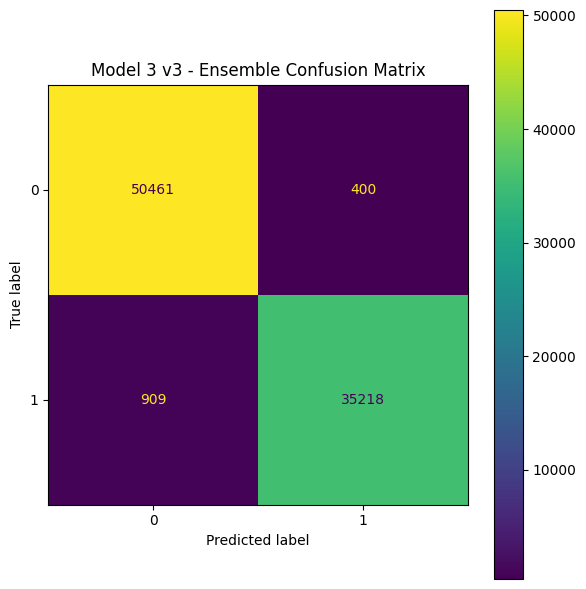

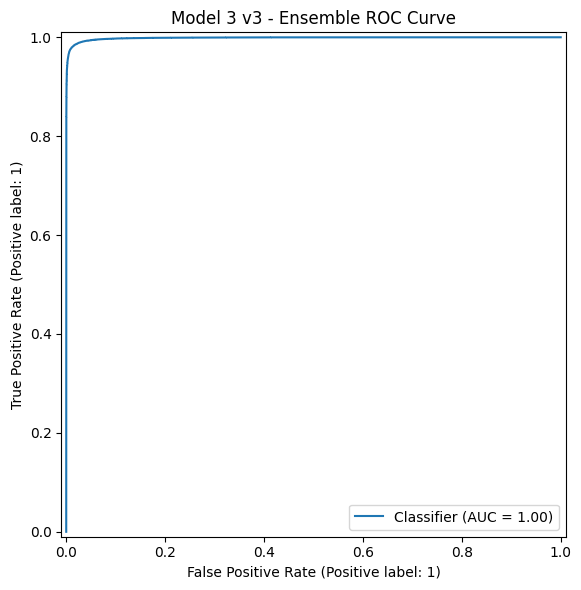

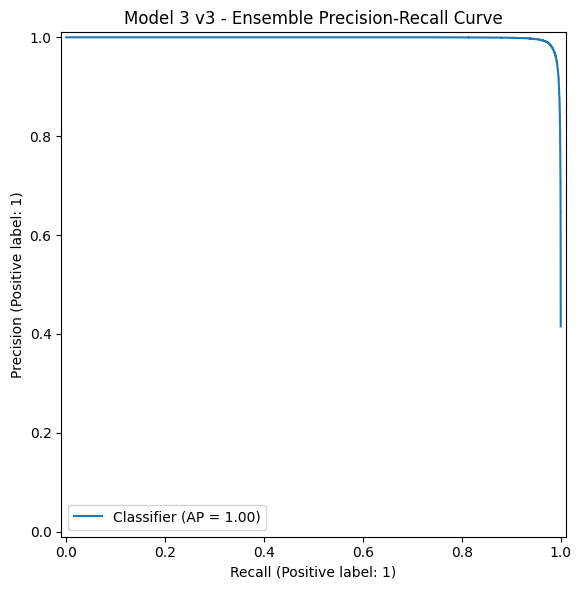

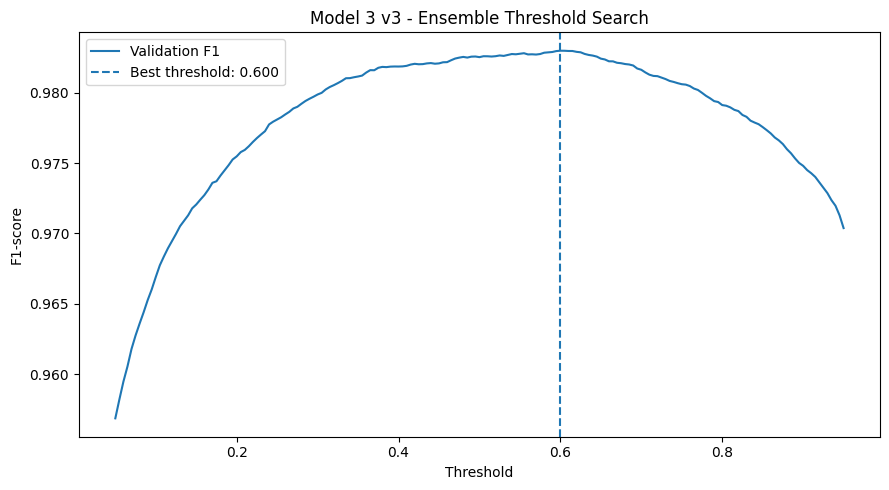


ZIP CREATED
ZIP path: /kaggle/working/model_3_v3_cnn_bilstm_seed_ensemble_complete.zip
ZIP size: 13.11 MB

ZIP content:
- arrays/
- config/
- logs/
- models/
- plots/
- results/
- file_manifest.csv
- models/model_3_v3_seed_42.keras
- models/model_3_v3_seed_2024.keras
- models/model_3_v3_seed_3407.keras
- arrays/seed_2024_test_probabilities.npy
- arrays/y_test.npy
- arrays/ensemble_test_probabilities.npy
- arrays/seed_3407_test_probabilities.npy
- arrays/seed_2024_validation_probabilities.npy
- arrays/ensemble_test_predictions.npy
- arrays/seed_3407_validation_probabilities.npy
- arrays/seed_42_validation_probabilities.npy
- arrays/seed_42_test_probabilities.npy
- arrays/y_validation.npy
- arrays/ensemble_validation_probabilities.npy
- plots/model_3_v3_ensemble_roc_curve.png
- plots/model_3_v3_ensemble_precision_recall_curve.png
- plots/model_3_v3_ensemble_confusion_matrix.png
- plots/model_3_v3_ensemble_threshold_search.png
- logs/model_3_v3_seed_2024_history.csv
- logs/model_3_v3_see

/kaggle/working/model_3_v3_cnn_bilstm_seed_ensemble_complete.zip


MODEL 3 v3 PROCESS COMPLETED
Seeds: [42, 2024, 3407]
Best validation threshold: 0.5999999999999998
Best validation F1: 0.9829700652210268
Test accuracy: 0.984951947395043
Test precision: 0.9887697231736763
Test recall: 0.9748387632518615
Test F1: 0.9817548261202871
Test ROC-AUC: 0.9986128969043185
Test PR-AUC: 0.9982662340219847
Confusion matrix:
[[50461, 400], [909, 35218]]
ZIP: /kaggle/working/model_3_v3_cnn_bilstm_seed_ensemble_complete.zip


In [29]:
# ============================================================
# MODEL 3 v3 - DEEP CHARACTER CNN-BiLSTM SEED ENSEMBLE
# Seeds: 42, 2024, 3407
# Ensemble: Arithmetic Mean Probability Averaging
# ============================================================

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import gc
import json
import pickle
import random
import shutil
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    Dropout,
    Bidirectional,
    LSTM,
    Dense
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from IPython.display import FileLink, display


# ============================================================
# 1. GENEL AYARLAR
# ============================================================

CSV_PATH = (
    "/kaggle/input/datasets/elifzelik/"
    "phishing-url-features-dataset/final_dataset.csv"
)

SEEDS = [42, 2024, 3407]

MAX_LEN = 250
MAX_CHARS = 150

EMBEDDING_DIM = 96

CNN_FILTERS_1 = 128
CNN_KERNEL_SIZE_1 = 5

CNN_FILTERS_2 = 128
CNN_KERNEL_SIZE_2 = 3

LSTM_UNITS = 96

CNN_DROPOUT_1 = 0.20
CNN_DROPOUT_2 = 0.20

DENSE_UNITS_1 = 128
DENSE_UNITS_2 = 64

DENSE_DROPOUT_1 = 0.30
DENSE_DROPOUT_2 = 0.20

LEARNING_RATE = 5e-4
BATCH_SIZE = 256
PREDICTION_BATCH_SIZE = 512
EPOCHS = 35

BASE_SAVE_DIR = (
    "/kaggle/working/"
    "model_3_v3_cnn_bilstm_seed_ensemble"
)

MODEL_DIR = f"{BASE_SAVE_DIR}/models"
RESULT_DIR = f"{BASE_SAVE_DIR}/results"
ARRAY_DIR = f"{BASE_SAVE_DIR}/arrays"
CONFIG_DIR = f"{BASE_SAVE_DIR}/config"
LOG_DIR = f"{BASE_SAVE_DIR}/logs"
PLOT_DIR = f"{BASE_SAVE_DIR}/plots"

for directory in [
    BASE_SAVE_DIR,
    MODEL_DIR,
    RESULT_DIR,
    ARRAY_DIR,
    CONFIG_DIR,
    LOG_DIR,
    PLOT_DIR
]:
    os.makedirs(directory, exist_ok=True)

print("=" * 75)
print("MODEL 3 v3 - DEEP CNN-BiLSTM SEED ENSEMBLE")
print("=" * 75)
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("Seeds:", SEEDS)
print("Kayıt klasörü:", BASE_SAVE_DIR)


# ============================================================
# 2. SEED AYARLAMA FONKSİYONU
# ============================================================

def set_all_seeds(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    try:
        tf.keras.utils.set_random_seed(seed)
    except Exception:
        pass

    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


# Veri bölünmesi tüm modeller için seed 42 ile sabittir.
set_all_seeds(42)


# ============================================================
# 3. DATASET YÜKLEME
# ============================================================

print("\n" + "=" * 75)
print("DATASET LOADING")
print("=" * 75)

df = pd.read_csv(
    CSV_PATH,
    usecols=["url", "label"]
)

df = df.dropna(
    subset=["url", "label"]
).copy()

df["url"] = df["url"].astype(str)
df["label"] = df["label"].astype(np.int8)

print("Dataset shape:", df.shape)

print("\nLabel counts:")
print(df["label"].value_counts().sort_index())

print("\nLabel ratios:")
print(df["label"].value_counts(normalize=True).sort_index())


# ============================================================
# 4. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

urls = df["url"].to_numpy()
labels = df["label"].to_numpy()

X_train_url, X_temp_url, y_train, y_temp = train_test_split(
    urls,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

X_val_url, X_test_url, y_val, y_test = train_test_split(
    X_temp_url,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\n" + "=" * 75)
print("DATA SPLIT")
print("=" * 75)

print("Train:", len(X_train_url))
print("Validation:", len(X_val_url))
print("Test:", len(X_test_url))

print("\nTrain labels:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation labels:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest labels:")
print(pd.Series(y_test).value_counts().sort_index())

np.save(
    f"{ARRAY_DIR}/y_validation.npy",
    y_val
)

np.save(
    f"{ARRAY_DIR}/y_test.npy",
    y_test
)


# ============================================================
# 5. SPLIT BİLGİLERİNİ KAYDET
# ============================================================

split_information = {
    "dataset_path": CSV_PATH,
    "total_samples": int(len(df)),
    "train_samples": int(len(X_train_url)),
    "validation_samples": int(len(X_val_url)),
    "test_samples": int(len(X_test_url)),
    "train_ratio": 0.70,
    "validation_ratio": 0.15,
    "test_ratio": 0.15,
    "split_random_state": 42,
    "stratified": True,
    "duplicate_urls_removed": False,
    "train_label_counts": {
        str(key): int(value)
        for key, value in pd.Series(
            y_train
        ).value_counts().sort_index().to_dict().items()
    },
    "validation_label_counts": {
        str(key): int(value)
        for key, value in pd.Series(
            y_val
        ).value_counts().sort_index().to_dict().items()
    },
    "test_label_counts": {
        str(key): int(value)
        for key, value in pd.Series(
            y_test
        ).value_counts().sort_index().to_dict().items()
    }
}

with open(
    f"{CONFIG_DIR}/data_split_information.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        split_information,
        file,
        indent=4,
        ensure_ascii=False
    )


# ============================================================
# 6. CHARACTER TOKENIZER
# ============================================================

tokenizer = Tokenizer(
    num_words=MAX_CHARS,
    char_level=True,
    lower=False,
    oov_token="<OOV>"
)

# Veri sızıntısını engellemek için yalnızca train setinde öğrenir.
tokenizer.fit_on_texts(X_train_url)

vocab_size = min(
    MAX_CHARS,
    len(tokenizer.word_index) + 1
)

print("\nTokenizer karakter sayısı:", len(tokenizer.word_index))
print("Model vocabulary size:", vocab_size)

with open(
    f"{CONFIG_DIR}/url_character_tokenizer.pkl",
    "wb"
) as file:
    pickle.dump(tokenizer, file)

with open(
    f"{CONFIG_DIR}/url_character_tokenizer.json",
    "w",
    encoding="utf-8"
) as file:
    file.write(tokenizer.to_json())


# ============================================================
# 7. SEQUENCE VE PADDING
# ============================================================

print("\nSequence dönüşümü yapılıyor...")

X_train_sequences = tokenizer.texts_to_sequences(
    X_train_url
)

X_val_sequences = tokenizer.texts_to_sequences(
    X_val_url
)

X_test_sequences = tokenizer.texts_to_sequences(
    X_test_url
)

X_train_pad = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    dtype="int32"
)

X_val_pad = pad_sequences(
    X_val_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    dtype="int32"
)

X_test_pad = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    dtype="int32"
)

print("Train shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Test shape:", X_test_pad.shape)

del X_train_sequences
del X_val_sequences
del X_test_sequences

gc.collect()


# ============================================================
# 8. CLASS WEIGHT
# ============================================================

classes = np.unique(y_train)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = {
    int(label): float(weight)
    for label, weight in zip(
        classes,
        class_weight_values
    )
}

print("\nClass weights:", class_weight)


# ============================================================
# 9. MODEL OLUŞTURMA FONKSİYONU
# ============================================================

def create_deep_cnn_bilstm_model(
    vocab_size,
    max_len,
    learning_rate=5e-4
):
    model = Sequential([
        Input(
            shape=(max_len,),
            name="url_character_input"
        ),

        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            name="character_embedding"
        ),

        Conv1D(
            filters=CNN_FILTERS_1,
            kernel_size=CNN_KERNEL_SIZE_1,
            padding="same",
            activation="relu",
            name="conv1d_block_1"
        ),

        BatchNormalization(
            name="conv_batch_normalization_1"
        ),

        MaxPooling1D(
            pool_size=2,
            name="max_pooling_1"
        ),

        Dropout(
            CNN_DROPOUT_1,
            name="cnn_dropout_1"
        ),

        Conv1D(
            filters=CNN_FILTERS_2,
            kernel_size=CNN_KERNEL_SIZE_2,
            padding="same",
            activation="relu",
            name="conv1d_block_2"
        ),

        BatchNormalization(
            name="conv_batch_normalization_2"
        ),

        MaxPooling1D(
            pool_size=2,
            name="max_pooling_2"
        ),

        Dropout(
            CNN_DROPOUT_2,
            name="cnn_dropout_2"
        ),

        Bidirectional(
            LSTM(
                LSTM_UNITS,
                return_sequences=False,
                dropout=0.0,
                recurrent_dropout=0.0
            ),
            name="bidirectional_lstm"
        ),

        BatchNormalization(
            name="lstm_batch_normalization"
        ),

        Dense(
            DENSE_UNITS_1,
            activation="relu",
            name="dense_128"
        ),

        Dropout(
            DENSE_DROPOUT_1,
            name="dense_dropout_128"
        ),

        Dense(
            DENSE_UNITS_2,
            activation="relu",
            name="dense_64"
        ),

        Dropout(
            DENSE_DROPOUT_2,
            name="dense_dropout_64"
        ),

        Dense(
            1,
            activation="sigmoid",
            name="output"
        )
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",

            tf.keras.metrics.AUC(
                name="auc",
                curve="ROC"
            ),

            tf.keras.metrics.AUC(
                name="pr_auc",
                curve="PR"
            )
        ]
    )

    return model


# ============================================================
# 10. CALLBACK FONKSİYONU
# ============================================================

def build_callbacks(seed):
    model_path = (
        f"{MODEL_DIR}/"
        f"model_3_v3_seed_{seed}.keras"
    )

    return [
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),

        ModelCheckpoint(
            filepath=model_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),

        CSVLogger(
            filename=(
                f"{LOG_DIR}/"
                f"model_3_v3_seed_{seed}_training_log.csv"
            ),
            append=False
        )
    ]


# ============================================================
# 11. THRESHOLD ARAMA FONKSİYONU
# ============================================================

def find_best_threshold(
    y_true,
    y_probability,
    start=0.05,
    stop=0.95,
    step=0.005
):
    thresholds = np.arange(
        start,
        stop + step,
        step
    )

    records = []

    best_threshold = 0.5
    best_f1 = -1.0

    for threshold in thresholds:
        predictions = (
            y_probability >= threshold
        ).astype(np.int8)

        precision = precision_score(
            y_true,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            predictions,
            zero_division=0
        )

        records.append({
            "threshold": float(threshold),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1)
        })

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    return (
        float(best_threshold),
        float(best_f1),
        pd.DataFrame(records)
    )


# ============================================================
# 12. DEĞERLENDİRME FONKSİYONU
# ============================================================

def calculate_metrics(
    y_true,
    y_probability,
    threshold,
    model_name
):
    predictions = (
        y_probability >= threshold
    ).astype(np.int8)

    matrix = confusion_matrix(
        y_true,
        predictions
    )

    tn, fp, fn, tp = matrix.ravel()

    result = {
        "Model": model_name,
        "Threshold": float(threshold),
        "Accuracy": float(
            accuracy_score(
                y_true,
                predictions
            )
        ),
        "Precision": float(
            precision_score(
                y_true,
                predictions,
                zero_division=0
            )
        ),
        "Recall": float(
            recall_score(
                y_true,
                predictions,
                zero_division=0
            )
        ),
        "F1-score": float(
            f1_score(
                y_true,
                predictions,
                zero_division=0
            )
        ),
        "ROC-AUC": float(
            roc_auc_score(
                y_true,
                y_probability
            )
        ),
        "PR-AUC": float(
            average_precision_score(
                y_true,
                y_probability
            )
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

    return result, predictions


# ============================================================
# 13. MODEL 3 v2 SEED-42 MODELİNİ BULMA
# ============================================================

V2_MODEL_CANDIDATES = [
    (
        "/kaggle/working/"
        "model_3_v2_deep_cnn_bilstm/models/"
        "model_3_v2_deep_character_cnn_bilstm.keras"
    ),
    (
        "/kaggle/working/"
        "model_3_v2_deep_cnn_bilstm/models/"
        "model_3_v2_deep_cnn_bilstm_final.keras"
    )
]

existing_seed_42_path = None

for candidate in V2_MODEL_CANDIDATES:
    if os.path.exists(candidate):
        existing_seed_42_path = candidate
        break

if existing_seed_42_path:
    print(
        "\nSeed 42 için mevcut v2 modeli bulundu:",
        existing_seed_42_path
    )
else:
    print(
        "\nSeed 42 v2 modeli bulunamadı."
        "\nSeed 42 modeli yeniden eğitilecek."
    )


# ============================================================
# 14. ÜÇ SEED İÇİN MODEL EĞİTİMİ / TAHMİN
# ============================================================

validation_probability_list = []
test_probability_list = []

individual_results = []
training_summary_records = []

for seed in SEEDS:
    print("\n" + "#" * 75)
    print(f"SEED {seed}")
    print("#" * 75)

    set_all_seeds(seed)

    tf.keras.backend.clear_session()
    gc.collect()

    seed_model_path = (
        f"{MODEL_DIR}/"
        f"model_3_v3_seed_{seed}.keras"
    )

    # Seed 42 modeli mevcut v2 modelinden kopyalanabilir.
    if (
        seed == 42
        and existing_seed_42_path is not None
    ):
        shutil.copy2(
            existing_seed_42_path,
            seed_model_path
        )

        model = load_model(seed_model_path)

        best_epoch = 20
        best_validation_loss = 0.05080853030085564

        print(
            "Seed 42 modeli yeniden eğitilmeden "
            "mevcut v2 dosyasından yüklendi."
        )

    else:
        model = create_deep_cnn_bilstm_model(
            vocab_size=vocab_size,
            max_len=MAX_LEN,
            learning_rate=LEARNING_RATE
        )

        print(f"\nSeed {seed} model özeti:")

        if seed == SEEDS[0]:
            model.summary()

        history = model.fit(
            X_train_pad,
            y_train,

            validation_data=(
                X_val_pad,
                y_val
            ),

            epochs=EPOCHS,
            batch_size=BATCH_SIZE,

            class_weight=class_weight,

            callbacks=build_callbacks(seed),

            verbose=1
        )

        history_dataframe = pd.DataFrame(
            history.history
        )

        history_dataframe.index = (
            history_dataframe.index + 1
        )

        history_dataframe.index.name = "epoch"

        history_dataframe.to_csv(
            f"{LOG_DIR}/"
            f"model_3_v3_seed_{seed}_history.csv"
        )

        best_epoch = int(
            history_dataframe["val_loss"].idxmin()
        )

        best_validation_loss = float(
            history_dataframe["val_loss"].min()
        )

        # EarlyStopping restore_best_weights kullandığı için
        # model bellekte en iyi epoch ağırlıklarına dönmüştür.
        model.save(seed_model_path)

    print(
        f"Seed {seed} validation tahminleri alınıyor..."
    )

    seed_validation_probabilities = model.predict(
        X_val_pad,
        batch_size=PREDICTION_BATCH_SIZE,
        verbose=1
    ).ravel()

    print(
        f"Seed {seed} test tahminleri alınıyor..."
    )

    seed_test_probabilities = model.predict(
        X_test_pad,
        batch_size=PREDICTION_BATCH_SIZE,
        verbose=1
    ).ravel()

    np.save(
        f"{ARRAY_DIR}/"
        f"seed_{seed}_validation_probabilities.npy",
        seed_validation_probabilities
    )

    np.save(
        f"{ARRAY_DIR}/"
        f"seed_{seed}_test_probabilities.npy",
        seed_test_probabilities
    )

    (
        seed_best_threshold,
        seed_best_validation_f1,
        seed_threshold_dataframe
    ) = find_best_threshold(
        y_val,
        seed_validation_probabilities
    )

    seed_threshold_dataframe.to_csv(
        f"{RESULT_DIR}/"
        f"seed_{seed}_threshold_search.csv",
        index=False
    )

    seed_result, seed_test_predictions = (
        calculate_metrics(
            y_true=y_test,
            y_probability=seed_test_probabilities,
            threshold=seed_best_threshold,
            model_name=(
                "Model 3 v3 CNN-BiLSTM "
                f"Seed {seed}"
            )
        )
    )

    seed_result["Seed"] = seed
    seed_result["Validation F1"] = (
        seed_best_validation_f1
    )
    seed_result["Best Epoch"] = best_epoch
    seed_result["Best Validation Loss"] = (
        best_validation_loss
    )

    individual_results.append(seed_result)

    training_summary_records.append({
        "seed": seed,
        "best_epoch": best_epoch,
        "best_validation_loss": (
            best_validation_loss
        ),
        "best_threshold": (
            seed_best_threshold
        ),
        "best_validation_f1": (
            seed_best_validation_f1
        )
    })

    validation_probability_list.append(
        seed_validation_probabilities
    )

    test_probability_list.append(
        seed_test_probabilities
    )

    print("\nIndividual seed result:")
    print(seed_result)

    del model
    gc.collect()


# ============================================================
# 15. INDIVIDUAL SEED SONUÇLARINI KAYDET
# ============================================================

individual_results_dataframe = pd.DataFrame(
    individual_results
)

individual_results_dataframe.to_csv(
    f"{RESULT_DIR}/"
    "model_3_v3_individual_seed_results.csv",
    index=False
)

training_summary_dataframe = pd.DataFrame(
    training_summary_records
)

training_summary_dataframe.to_csv(
    f"{RESULT_DIR}/"
    "model_3_v3_seed_training_summary.csv",
    index=False
)

print("\nIndividual seed results:")
print(individual_results_dataframe)


# ============================================================
# 16. ENSEMBLE OLASILIK ORTALAMASI
# ============================================================

ensemble_validation_probabilities = np.mean(
    np.stack(
        validation_probability_list,
        axis=0
    ),
    axis=0
)

ensemble_test_probabilities = np.mean(
    np.stack(
        test_probability_list,
        axis=0
    ),
    axis=0
)

np.save(
    f"{ARRAY_DIR}/"
    "ensemble_validation_probabilities.npy",
    ensemble_validation_probabilities
)

np.save(
    f"{ARRAY_DIR}/"
    "ensemble_test_probabilities.npy",
    ensemble_test_probabilities
)


# ============================================================
# 17. ENSEMBLE THRESHOLD SEÇİMİ
# ============================================================

(
    ensemble_best_threshold,
    ensemble_best_validation_f1,
    ensemble_threshold_dataframe
) = find_best_threshold(
    y_val,
    ensemble_validation_probabilities
)

ensemble_threshold_dataframe.to_csv(
    f"{RESULT_DIR}/"
    "model_3_v3_ensemble_threshold_search.csv",
    index=False
)

print("\n" + "=" * 75)
print("ENSEMBLE VALIDATION RESULT")
print("=" * 75)

print(
    "Best ensemble threshold:",
    ensemble_best_threshold
)

print(
    "Best ensemble validation F1:",
    ensemble_best_validation_f1
)

print("\nEn iyi 15 threshold:")

print(
    ensemble_threshold_dataframe
    .sort_values(
        "f1",
        ascending=False
    )
    .head(15)
)


# ============================================================
# 18. ENSEMBLE TEST DEĞERLENDİRMESİ
# ============================================================

ensemble_result, ensemble_test_predictions = (
    calculate_metrics(
        y_true=y_test,
        y_probability=ensemble_test_probabilities,
        threshold=ensemble_best_threshold,
        model_name=(
            "Model 3 v3 - Deep Character "
            "CNN-BiLSTM Seed Ensemble"
        )
    )
)

ensemble_result["Validation F1"] = float(
    ensemble_best_validation_f1
)

ensemble_result["Seeds"] = ",".join(
    map(str, SEEDS)
)

ensemble_result["Ensemble Method"] = (
    "Arithmetic mean probability averaging"
)

np.save(
    f"{ARRAY_DIR}/"
    "ensemble_test_predictions.npy",
    ensemble_test_predictions
)

print("\n" + "=" * 75)
print("MODEL 3 v3 FINAL ENSEMBLE RESULT")
print("=" * 75)

print(
    classification_report(
        y_test,
        ensemble_test_predictions,
        digits=6,
        zero_division=0
    )
)

print("Confusion Matrix:")

ensemble_confusion_matrix = confusion_matrix(
    y_test,
    ensemble_test_predictions
)

print(ensemble_confusion_matrix)

print("\nFinal result dictionary:")
print(ensemble_result)


# ============================================================
# 19. FINAL SONUÇLARI KAYDET
# ============================================================

ensemble_result_dataframe = pd.DataFrame([
    ensemble_result
])

ensemble_result_dataframe.to_csv(
    f"{RESULT_DIR}/"
    "model_3_v3_ensemble_results.csv",
    index=False
)

with open(
    f"{RESULT_DIR}/"
    "model_3_v3_ensemble_results.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        ensemble_result,
        file,
        indent=4,
        ensure_ascii=False
    )


# ============================================================
# 20. V1, V2 VE V3 KARŞILAŞTIRMASI
# ============================================================

model_3_versions_comparison = pd.DataFrame([
    {
        "Model": (
            "Model 3 v1 - Character CNN-BiLSTM"
        ),
        "Threshold": 0.385,
        "Accuracy": 0.9811698165264174,
        "Precision": 0.9783627839884601,
        "Recall": 0.9762504498020871,
        "F1-score": 0.9773054755043228,
        "ROC-AUC": 0.9979868280848079,
        "PR-AUC": 0.9975354079375912,
        "TN": 50081,
        "FP": 780,
        "FN": 858,
        "TP": 35269
    },

    {
        "Model": (
            "Model 3 v2 - Deep Character "
            "CNN-BiLSTM"
        ),
        "Threshold": 0.585,
        "Accuracy": 0.9829746631719317,
        "Precision": 0.9855100896860987,
        "Recall": 0.9733163561878927,
        "F1-score": 0.9793752698204911,
        "ROC-AUC": 0.9982321692849279,
        "PR-AUC": 0.9978439480489755,
        "TN": 50344,
        "FP": 517,
        "FN": 964,
        "TP": 35163
    },

    ensemble_result
])

model_3_versions_comparison.to_csv(
    f"{RESULT_DIR}/"
    "model_3_v1_v2_v3_comparison.csv",
    index=False
)

print("\n" + "=" * 75)
print("MODEL 3 VERSION COMPARISON")
print("=" * 75)

print(model_3_versions_comparison)


# ============================================================
# 21. TÜM FINAL MODELLERLE KARŞILAŞTIRMA
# ============================================================

all_final_models_comparison = pd.DataFrame([
    {
        "Model": (
            "Model 1 - Character CNN Seed Ensemble"
        ),
        "Threshold": 0.410,
        "Accuracy": 0.9837678760288775,
        "Precision": 0.9861636277063552,
        "Recall": 0.9745896420959393,
        "F1-score": 0.9803424752888765,
        "ROC-AUC": 0.9984950774425538,
        "PR-AUC": 0.9981095389818174,
        "TN": 50367,
        "FP": 494,
        "FN": 918,
        "TP": 35209
    },

    {
        "Model": (
            "Model 2 - Stacked Character "
            "BiLSTM Seed Ensemble"
        ),
        "Threshold": 0.515,
        "Accuracy": 0.9800432243527842,
        "Precision": 0.9817611296332615,
        "Recall": 0.9699670606471614,
        "F1-score": 0.9758284600389864,
        "ROC-AUC": 0.9975758654449631,
        "PR-AUC": 0.997075478812562,
        "TN": 50210,
        "FP": 651,
        "FN": 1085,
        "TP": 35042
    },

    {
        "Model": (
            "Model 3 v2 - Deep Character "
            "CNN-BiLSTM"
        ),
        "Threshold": 0.585,
        "Accuracy": 0.9829746631719317,
        "Precision": 0.9855100896860987,
        "Recall": 0.9733163561878927,
        "F1-score": 0.9793752698204911,
        "ROC-AUC": 0.9982321692849279,
        "PR-AUC": 0.9978439480489755,
        "TN": 50344,
        "FP": 517,
        "FN": 964,
        "TP": 35163
    },

    ensemble_result
])

all_final_models_comparison.to_csv(
    f"{RESULT_DIR}/"
    "all_final_models_comparison.csv",
    index=False
)

print("\n" + "=" * 75)
print("ALL FINAL MODEL COMPARISON")
print("=" * 75)

print(all_final_models_comparison)


# ============================================================
# 22. CONFUSION MATRIX GRAFİĞİ
# ============================================================

figure, axis = plt.subplots(
    figsize=(6, 6)
)

ConfusionMatrixDisplay(
    confusion_matrix=ensemble_confusion_matrix,
    display_labels=[0, 1]
).plot(
    ax=axis,
    values_format="d"
)

axis.set_title(
    "Model 3 v3 - Ensemble Confusion Matrix"
)

figure.tight_layout()

figure.savefig(
    f"{PLOT_DIR}/"
    "model_3_v3_ensemble_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(figure)


# ============================================================
# 23. ROC CURVE
# ============================================================

figure, axis = plt.subplots(
    figsize=(7, 6)
)

RocCurveDisplay.from_predictions(
    y_test,
    ensemble_test_probabilities,
    ax=axis
)

axis.set_title(
    "Model 3 v3 - Ensemble ROC Curve"
)

figure.tight_layout()

figure.savefig(
    f"{PLOT_DIR}/"
    "model_3_v3_ensemble_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(figure)


# ============================================================
# 24. PRECISION-RECALL CURVE
# ============================================================

figure, axis = plt.subplots(
    figsize=(7, 6)
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    ensemble_test_probabilities,
    ax=axis
)

axis.set_title(
    "Model 3 v3 - Ensemble Precision-Recall Curve"
)

figure.tight_layout()

figure.savefig(
    f"{PLOT_DIR}/"
    "model_3_v3_ensemble_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(figure)


# ============================================================
# 25. THRESHOLD GRAFİĞİ
# ============================================================

figure, axis = plt.subplots(
    figsize=(9, 5)
)

axis.plot(
    ensemble_threshold_dataframe["threshold"],
    ensemble_threshold_dataframe["f1"],
    label="Validation F1"
)

axis.axvline(
    ensemble_best_threshold,
    linestyle="--",
    label=(
        f"Best threshold: "
        f"{ensemble_best_threshold:.3f}"
    )
)

axis.set_title(
    "Model 3 v3 - Ensemble Threshold Search"
)

axis.set_xlabel("Threshold")
axis.set_ylabel("F1-score")
axis.legend()

figure.tight_layout()

figure.savefig(
    f"{PLOT_DIR}/"
    "model_3_v3_ensemble_threshold_search.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(figure)


# ============================================================
# 26. KONFİGÜRASYON DOSYASI
# ============================================================

ensemble_configuration = {
    "model_name": (
        "Model 3 v3 - Deep Character "
        "CNN-BiLSTM Seed Ensemble"
    ),

    "base_architecture": (
        "Model 3 v2 - Deep Character CNN-BiLSTM"
    ),

    "input": "Raw URL characters only",

    "handcrafted_features_used": False,

    "dataset_path": CSV_PATH,

    "data_split_random_state": 42,

    "seeds": SEEDS,

    "ensemble_method": (
        "Arithmetic mean probability averaging"
    ),

    "threshold_selection": (
        "Maximum F1-score on validation set"
    ),

    "preprocessing": {
        "max_len": MAX_LEN,
        "max_chars": MAX_CHARS,
        "vocab_size": int(vocab_size),
        "character_level": True,
        "lower": False,
        "oov_token": "<OOV>",
        "padding": "post",
        "truncating": "post"
    },

    "architecture": {
        "embedding_dim": EMBEDDING_DIM,

        "cnn_block_1": {
            "filters": CNN_FILTERS_1,
            "kernel_size": CNN_KERNEL_SIZE_1,
            "padding": "same",
            "activation": "relu",
            "pool_size": 2,
            "dropout": CNN_DROPOUT_1
        },

        "cnn_block_2": {
            "filters": CNN_FILTERS_2,
            "kernel_size": CNN_KERNEL_SIZE_2,
            "padding": "same",
            "activation": "relu",
            "pool_size": 2,
            "dropout": CNN_DROPOUT_2
        },

        "bilstm_units_per_direction": LSTM_UNITS,

        "dense_units": [
            DENSE_UNITS_1,
            DENSE_UNITS_2
        ],

        "dense_dropouts": [
            DENSE_DROPOUT_1,
            DENSE_DROPOUT_2
        ]
    },

    "training": {
        "optimizer": "Adam",
        "initial_learning_rate": LEARNING_RATE,
        "loss": "binary_crossentropy",
        "batch_size": BATCH_SIZE,
        "maximum_epochs": EPOCHS,
        "class_weight": {
            str(key): float(value)
            for key, value in class_weight.items()
        }
    },

    "final_threshold": (
        ensemble_best_threshold
    ),

    "validation_f1": (
        ensemble_best_validation_f1
    )
}

with open(
    f"{CONFIG_DIR}/"
    "model_3_v3_ensemble_configuration.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        ensemble_configuration,
        file,
        indent=4,
        ensure_ascii=False
    )


# ============================================================
# 27. FINAL RAPOR
# ============================================================

final_report = f"""
MODEL 3 v3 FINAL REPORT
=======================

Model:
Model 3 v3 - Deep Character CNN-BiLSTM Seed Ensemble

Base Architecture:
Model 3 v2 - Deep Character CNN-BiLSTM

Input:
Raw URL characters only

Handcrafted Features:
Not used

Dataset:
{CSV_PATH}

Data Split:
- Train: 70%
- Validation: 15%
- Test: 15%
- Split random state: 42
- Stratified: Yes

Seeds:
{SEEDS}

Ensemble Method:
Arithmetic mean probability averaging

Preprocessing:
- Character-level tokenizer
- Maximum character count: {MAX_CHARS}
- Vocabulary size: {vocab_size}
- Maximum URL length: {MAX_LEN}
- Padding: post
- Truncating: post

Validation:
- Best threshold: {ensemble_best_threshold}
- Best validation F1: {ensemble_best_validation_f1}

Final Test Results:
- Accuracy: {ensemble_result["Accuracy"]}
- Precision: {ensemble_result["Precision"]}
- Recall: {ensemble_result["Recall"]}
- F1-score: {ensemble_result["F1-score"]}
- ROC-AUC: {ensemble_result["ROC-AUC"]}
- PR-AUC: {ensemble_result["PR-AUC"]}

Confusion Matrix:
- TN: {ensemble_result["TN"]}
- FP: {ensemble_result["FP"]}
- FN: {ensemble_result["FN"]}
- TP: {ensemble_result["TP"]}
"""

with open(
    f"{RESULT_DIR}/"
    "model_3_v3_final_report.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(final_report)


# ============================================================
# 28. MANIFEST OLUŞTUR
# ============================================================

manifest_records = []

for root, directories, files in os.walk(
    BASE_SAVE_DIR
):
    for filename in files:
        full_path = os.path.join(
            root,
            filename
        )

        relative_path = os.path.relpath(
            full_path,
            BASE_SAVE_DIR
        )

        size_bytes = os.path.getsize(
            full_path
        )

        manifest_records.append({
            "file": relative_path,
            "size_bytes": int(size_bytes),
            "size_kb": float(size_bytes / 1024)
        })

manifest_dataframe = pd.DataFrame(
    manifest_records
).sort_values("file")

manifest_dataframe.to_csv(
    f"{BASE_SAVE_DIR}/file_manifest.csv",
    index=False
)


# ============================================================
# 29. ZIP OLUŞTUR
# ============================================================

ZIP_BASE = (
    "/kaggle/working/"
    "model_3_v3_cnn_bilstm_seed_ensemble_complete"
)

zip_path = shutil.make_archive(
    base_name=ZIP_BASE,
    format="zip",
    root_dir=BASE_SAVE_DIR
)

print("\n" + "=" * 75)
print("ZIP CREATED")
print("=" * 75)

print("ZIP path:", zip_path)

print(
    "ZIP size:",
    round(
        os.path.getsize(zip_path)
        / (1024 ** 2),
        2
    ),
    "MB"
)


# ============================================================
# 30. ZIP İÇERİĞİNİ KONTROL ET
# ============================================================

print("\nZIP content:")

with zipfile.ZipFile(
    zip_path,
    "r"
) as zip_file:
    for filename in zip_file.namelist():
        print("-", filename)


# ============================================================
# 31. İNDİRME BAĞLANTISI
# ============================================================

print("\nZIP dosyasını aşağıdaki bağlantıdan indir:")

display(
    FileLink(zip_path)
)


# ============================================================
# 32. FINAL ÖZET
# ============================================================

print("\n" + "=" * 75)
print("MODEL 3 v3 PROCESS COMPLETED")
print("=" * 75)

print("Seeds:", SEEDS)

print(
    "Best validation threshold:",
    ensemble_best_threshold
)

print(
    "Best validation F1:",
    ensemble_best_validation_f1
)

print(
    "Test accuracy:",
    ensemble_result["Accuracy"]
)

print(
    "Test precision:",
    ensemble_result["Precision"]
)

print(
    "Test recall:",
    ensemble_result["Recall"]
)

print(
    "Test F1:",
    ensemble_result["F1-score"]
)

print(
    "Test ROC-AUC:",
    ensemble_result["ROC-AUC"]
)

print(
    "Test PR-AUC:",
    ensemble_result["PR-AUC"]
)

print("Confusion matrix:")

print([
    [
        ensemble_result["TN"],
        ensemble_result["FP"]
    ],
    [
        ensemble_result["FN"],
        ensemble_result["TP"]
    ]
])

print("ZIP:", zip_path)